# Graph Machine Learning Assignment

This notebook contains the complete assignment code (Q1-Q4).


## 0. Setup and Colab Requirements

Run the cell below to install missing dependencies and verify data.


In [7]:
!pip install numpy>=1.24 pandas>=2.0 matplotlib>=3.7 torch>=2.0

# Helper to download data if not available directly (Uncomment to use if you host it on GitHub):
# !wget https://raw.githubusercontent.com/YourUsername/YourRepo/main/nodes.csv
# !wget https://raw.githubusercontent.com/YourUsername/YourRepo/main/edges.csv
# !wget https://raw.githubusercontent.com/YourUsername/YourRepo/main/classes.csv




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1. Utility Functions (`utils_graph.py`)


In [13]:
import json
import math
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Set, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


@dataclass
class DatasetBundle:
    node_ids: np.ndarray
    x: torch.Tensor
    y: torch.Tensor
    edges_undirected: np.ndarray
    class_names: Dict[int, str]


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str) -> None:
    Path(path).mkdir(parents=True, exist_ok=True)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def choose_device(preference: str = "auto", min_free_gb: float = 1.5) -> torch.device:
    pref = preference.lower()
    if pref not in {"auto", "cpu", "cuda"}:
        raise ValueError("preference must be one of: auto, cpu, cuda")

    if pref == "cpu":
        return torch.device("cpu")

    if pref == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA requested but not available")
        return torch.device("cuda")

    if not torch.cuda.is_available():
        return torch.device("cpu")

    try:
        free_bytes, _ = torch.cuda.mem_get_info()
        if free_bytes >= int(min_free_gb * (1024 ** 3)):
            return torch.device("cuda")
        return torch.device("cpu")
    except Exception:
        return torch.device("cuda")


def unique_undirected_edges_preserve_order(edge_pairs: np.ndarray) -> np.ndarray:
    seen: Set[Tuple[int, int]] = set()
    uniq: List[Tuple[int, int]] = []
    for u, v in edge_pairs.tolist():
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        key = (int(a), int(b))
        if key in seen:
            continue
        seen.add(key)
        uniq.append(key)
    return np.asarray(uniq, dtype=np.int64)


def load_dataset(dataset_dir: str) -> DatasetBundle:
    dataset_path = Path(dataset_dir)
    nodes_df = pd.read_csv(dataset_path / "nodes.csv")
    edges_df = pd.read_csv(dataset_path / "edges.csv")
    classes_df = pd.read_csv(dataset_path / "classes.csv")

    required_node_cols = {"node_id", "label"}
    if not required_node_cols.issubset(nodes_df.columns):
        raise ValueError(f"nodes.csv must contain columns: {required_node_cols}")
    if not {"source", "target"}.issubset(edges_df.columns):
        raise ValueError("edges.csv must contain source,target")
    if not {"class_id", "class_name"}.issubset(classes_df.columns):
        raise ValueError("classes.csv must contain class_id,class_name")

    nodes_df = nodes_df.sort_values("node_id").reset_index(drop=True)
    node_ids = nodes_df["node_id"].to_numpy(dtype=np.int64)
    node_id_to_idx = {nid: idx for idx, nid in enumerate(node_ids.tolist())}

    feature_cols = [c for c in nodes_df.columns if c not in ("node_id", "label")]
    x_np = nodes_df[feature_cols].to_numpy(dtype=np.float32).copy()
    y_np = nodes_df["label"].to_numpy(dtype=np.int64).copy()

    raw_edges = edges_df[["source", "target"]].to_numpy(dtype=np.int64)
    mapped_edges: List[Tuple[int, int]] = []
    for s, t in raw_edges.tolist():
        if s not in node_id_to_idx or t not in node_id_to_idx:
            continue
        mapped_edges.append((node_id_to_idx[s], node_id_to_idx[t]))

    edges_undirected = unique_undirected_edges_preserve_order(np.asarray(mapped_edges, dtype=np.int64))

    class_names = {
        int(row.class_id): str(row.class_name)
        for row in classes_df.itertuples(index=False)
    }

    return DatasetBundle(
        node_ids=node_ids,
        x=torch.from_numpy(x_np),
        y=torch.from_numpy(y_np),
        edges_undirected=edges_undirected,
        class_names=class_names,
    )


def build_directed_edge_index(
    edges_undirected: np.ndarray,
    num_nodes: int,
    add_self_loops: bool = True,
) -> torch.Tensor:
    if edges_undirected.ndim != 2 or edges_undirected.shape[1] != 2:
        raise ValueError("edges_undirected must be shape [E, 2]")

    rev = edges_undirected[:, [1, 0]]
    directed = np.concatenate([edges_undirected, rev], axis=0)
    if add_self_loops:
        loops = np.arange(num_nodes, dtype=np.int64)
        loops = np.stack([loops, loops], axis=1)
        directed = np.concatenate([directed, loops], axis=0)

    directed_unique = np.unique(directed, axis=0)
    edge_index = torch.from_numpy(directed_unique.T).long()
    return edge_index


def stratified_split_indices(
    labels: np.ndarray,
    train_ratio: float,
    val_ratio: float,
    test_ratio: float,
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if not math.isclose(train_ratio + val_ratio + test_ratio, 1.0, rel_tol=0.0, abs_tol=1e-7):
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.0")

    rng = np.random.default_rng(seed)
    train_idx: List[int] = []
    val_idx: List[int] = []
    test_idx: List[int] = []

    classes = np.unique(labels)
    for cls in classes:
        cls_idx = np.where(labels == cls)[0]
        rng.shuffle(cls_idx)
        n = len(cls_idx)

        n_train = int(round(n * train_ratio))
        n_val = int(round(n * val_ratio))
        if n_train + n_val > n:
            n_val = max(0, n - n_train)
        n_test = n - n_train - n_val

        train_idx.extend(cls_idx[:n_train].tolist())
        val_idx.extend(cls_idx[n_train:n_train + n_val].tolist())
        test_idx.extend(cls_idx[n_train + n_val:n_train + n_val + n_test].tolist())

    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)
    test_idx = np.asarray(test_idx, dtype=np.int64)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)
    return train_idx, val_idx, test_idx


def mask_from_indices(num_nodes: int, indices: np.ndarray) -> torch.Tensor:
    mask = torch.zeros(num_nodes, dtype=torch.bool)
    mask[torch.from_numpy(indices)] = True
    return mask


def accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> float:
    pred = logits.argmax(dim=-1)
    return float((pred == labels).float().mean().item())


def roc_auc_binary(y_true: np.ndarray, y_score: np.ndarray) -> float:
    y_true = y_true.astype(np.int64)
    y_score = y_score.astype(np.float64)
    n_pos = int((y_true == 1).sum())
    n_neg = int((y_true == 0).sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    order = np.argsort(y_score, kind="mergesort")
    sorted_scores = y_score[order]

    ranks = np.empty(len(y_score), dtype=np.float64)
    i = 0
    while i < len(order):
        j = i + 1
        while j < len(order) and sorted_scores[j] == sorted_scores[i]:
            j += 1
        avg_rank = 0.5 * ((i + 1) + j)
        ranks[order[i:j]] = avg_rank
        i = j

    rank_sum_pos = ranks[y_true == 1].sum()
    auc = (rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)


def binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> Dict[str, float]:
    y_true = y_true.astype(np.int64)
    y_pred = (y_prob >= threshold).astype(np.int64)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2.0 * precision * recall / (precision + recall + 1e-12)
    acc = (tp + tn) / max(1, (tp + tn + fp + fn))

    return {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(acc),
        "tp": float(tp),
        "fp": float(fp),
        "tn": float(tn),
        "fn": float(fn),
    }


def find_best_threshold_by_f1(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    num_thresholds: int = 401,
) -> Tuple[float, Dict[str, float]]:
    best_threshold = 0.5
    best_metrics = binary_metrics(y_true, y_prob, best_threshold)
    for thr in np.linspace(0.0, 1.0, num_thresholds):
        m = binary_metrics(y_true, y_prob, float(thr))
        if m["f1"] > best_metrics["f1"]:
            best_threshold = float(thr)
            best_metrics = m
    return best_threshold, best_metrics


def pca_project_2d(x: np.ndarray) -> np.ndarray:
    x_centered = x - x.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(x_centered, full_matrices=False)
    proj = x_centered @ vt[:2].T
    return proj


def plot_embedding(
    emb_2d: np.ndarray,
    labels: np.ndarray,
    out_path: str,
    title: str,
    class_names: Optional[Dict[int, str]] = None,
) -> None:
    plt.figure(figsize=(10, 8))
    unique_labels = np.unique(labels)
    cmap = plt.get_cmap("tab10", len(unique_labels))

    for i, label in enumerate(unique_labels):
        mask = labels == label
        label_name = class_names.get(int(label), str(label)) if class_names else str(label)
        plt.scatter(
            emb_2d[mask, 0],
            emb_2d[mask, 1],
            s=8,
            alpha=0.7,
            label=label_name,
            color=cmap(i),
        )

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(markerscale=2.0, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()


def save_json(data: Dict, out_path: str) -> None:
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


def build_undirected_edge_set(edges: np.ndarray) -> Set[Tuple[int, int]]:
    out: Set[Tuple[int, int]] = set()
    for u, v in edges.tolist():
        a, b = (int(u), int(v)) if u < v else (int(v), int(u))
        if a != b:
            out.add((a, b))
    return out


def temporal_split_edges(
    edges_undirected_in_order: np.ndarray,
    train_ratio: float,
    val_ratio: float,
    test_ratio: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if not math.isclose(train_ratio + val_ratio + test_ratio, 1.0, rel_tol=0.0, abs_tol=1e-7):
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.0")

    n = edges_undirected_in_order.shape[0]
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    train_pos = edges_undirected_in_order[:n_train]
    val_pos = edges_undirected_in_order[n_train:n_train + n_val]
    test_pos = edges_undirected_in_order[n_train + n_val:n_train + n_val + n_test]
    return train_pos, val_pos, test_pos


def sample_negative_edges(
    num_nodes: int,
    num_samples: int,
    positive_edge_set: Set[Tuple[int, int]],
    rng: np.random.Generator,
    forbidden: Optional[Set[Tuple[int, int]]] = None,
) -> np.ndarray:
    chosen: Set[Tuple[int, int]] = set()
    if forbidden is None:
        forbidden = set()

    max_attempts = max(50_000, num_samples * 25)
    attempts = 0
    while len(chosen) < num_samples and attempts < max_attempts:
        u = int(rng.integers(0, num_nodes))
        v = int(rng.integers(0, num_nodes))
        attempts += 1
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        key = (a, b)
        if key in positive_edge_set or key in forbidden or key in chosen:
            continue
        chosen.add(key)

    if len(chosen) < num_samples:
        needed = num_samples - len(chosen)
        for u in range(num_nodes):
            if needed <= 0:
                break
            v = (u + 1) % num_nodes
            a, b = (u, v) if u < v else (v, u)
            key = (a, b)
            if key in positive_edge_set or key in forbidden or key in chosen or a == b:
                continue
            chosen.add(key)
            needed -= 1

    if len(chosen) < num_samples:
        raise RuntimeError("Unable to sample enough negative edges")

    return np.asarray(list(chosen), dtype=np.int64)


def build_neighbor_sets(num_nodes: int, edges_undirected: np.ndarray) -> List[Set[int]]:
    neighbors: List[Set[int]] = [set() for _ in range(num_nodes)]
    for u, v in edges_undirected.tolist():
        neighbors[int(u)].add(int(v))
        neighbors[int(v)].add(int(u))
    return neighbors


def sample_hard_negative_edges(
    num_nodes: int,
    num_samples: int,
    positive_edge_set: Set[Tuple[int, int]],
    neighbors: List[Set[int]],
    rng: np.random.Generator,
    hard_fraction: float = 0.5,
) -> np.ndarray:
    hard_target = int(num_samples * hard_fraction)
    chosen: Set[Tuple[int, int]] = set()

    nodes_with_neighbors = [i for i in range(num_nodes) if neighbors[i]]
    attempts = 0
    max_attempts = max(100_000, hard_target * 40)

    while len(chosen) < hard_target and attempts < max_attempts and nodes_with_neighbors:
        u = int(nodes_with_neighbors[int(rng.integers(0, len(nodes_with_neighbors)))])
        u_nei = list(neighbors[u])
        mid = int(u_nei[int(rng.integers(0, len(u_nei)))])
        second = neighbors[mid]
        if not second:
            attempts += 1
            continue
        v = int(list(second)[int(rng.integers(0, len(second)))])
        attempts += 1
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        key = (a, b)
        if key in positive_edge_set or key in chosen:
            continue
        chosen.add(key)

    needed_random = num_samples - len(chosen)
    random_part = sample_negative_edges(
        num_nodes=num_nodes,
        num_samples=needed_random,
        positive_edge_set=positive_edge_set,
        rng=rng,
        forbidden=chosen,
    )

    out = list(chosen)
    out.extend(map(tuple, random_part.tolist()))
    return np.asarray(out, dtype=np.int64)


def explain_q3_choice_text(train_ratio: float, val_ratio: float, test_ratio: float) -> str:
    return (
        "Future co-purchase is approximated with edge row order as pseudo-time. "
        f"Positive edges are split chronologically with ratio {train_ratio:.2f}/{val_ratio:.2f}/{test_ratio:.2f} "
        "for train/validation/test, so training only sees earlier edges and evaluation is on later edges. "
        "BCEWithLogitsLoss is used because link prediction is binary and this loss is numerically stable for logits-based training."
    )



## 2. Graph Models (`graph_models.py`)


In [9]:
from typing import Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F


class SparseGATLayer(nn.Module):
    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        heads: int = 4,
        dropout: float = 0.3,
        negative_slope: float = 0.2,
        concat: bool = True,
        edge_chunk_size: int = 100_000,
    ) -> None:
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.heads = heads
        self.concat = concat
        self.dropout = dropout
        self.negative_slope = negative_slope
        self.edge_chunk_size = edge_chunk_size

        self.lin = nn.Linear(in_dim, heads * out_dim, bias=False)
        self.att_src = nn.Parameter(torch.empty(heads, out_dim))
        self.att_dst = nn.Parameter(torch.empty(heads, out_dim))
        self.bias = nn.Parameter(torch.zeros(heads * out_dim if concat else out_dim))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.att_src)
        nn.init.xavier_uniform_(self.att_dst)
        nn.init.zeros_(self.bias)

    def _segment_softmax(self, scores: torch.Tensor, index: torch.Tensor, n_nodes: int) -> torch.Tensor:
        # scores: [E, H], index: [E]
        h = scores.size(1)
        index_exp = index.unsqueeze(-1).expand(-1, h)

        max_per_node = torch.full(
            (n_nodes, h),
            fill_value=-1.0e15,
            device=scores.device,
            dtype=scores.dtype,
        )
        max_per_node.scatter_reduce_(0, index_exp, scores, reduce="amax", include_self=True)

        norm_scores = scores - max_per_node[index]
        exp_scores = torch.exp(norm_scores)

        denom = torch.zeros((n_nodes, h), device=scores.device, dtype=scores.dtype)
        denom.scatter_add_(0, index_exp, exp_scores)

        alpha = exp_scores / (denom[index] + 1e-12)
        return alpha

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        n_nodes = x.size(0)
        src = edge_index[0]
        dst = edge_index[1]
        n_edges = src.size(0)

        x_proj = self.lin(x).view(n_nodes, self.heads, self.out_dim)

        # Compute attention scores in chunks to reduce peak memory on large graphs.
        att = torch.empty((n_edges, self.heads), device=x.device, dtype=x.dtype)
        for start in range(0, n_edges, self.edge_chunk_size):
            end = min(start + self.edge_chunk_size, n_edges)
            s = src[start:end]
            d = dst[start:end]
            x_src = x_proj[s]
            x_dst = x_proj[d]
            att_chunk = (x_src * self.att_src).sum(dim=-1) + (x_dst * self.att_dst).sum(dim=-1)
            att[start:end] = F.leaky_relu(att_chunk, negative_slope=self.negative_slope)

        alpha = self._segment_softmax(att, dst, n_nodes)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        out = torch.zeros(
            (n_nodes, self.heads, self.out_dim),
            device=x.device,
            dtype=x.dtype,
        )

        for start in range(0, n_edges, self.edge_chunk_size):
            end = min(start + self.edge_chunk_size, n_edges)
            s = src[start:end]
            d = dst[start:end]
            x_src = x_proj[s]
            alpha_chunk = alpha[start:end]
            messages = x_src * alpha_chunk.unsqueeze(-1)
            out.scatter_add_(0, d.view(-1, 1, 1).expand(-1, self.heads, self.out_dim), messages)

        if self.concat:
            out = out.reshape(n_nodes, self.heads * self.out_dim)
        else:
            out = out.mean(dim=1)

        out = out + self.bias
        return out


class GATNodeClassifier(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        heads: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.dropout = dropout
        self.gat1 = SparseGATLayer(in_dim=in_dim, out_dim=hidden_dim, heads=heads, dropout=dropout, concat=True)
        self.gat2 = SparseGATLayer(
            in_dim=hidden_dim * heads,
            out_dim=out_dim,
            heads=1,
            dropout=dropout,
            concat=False,
        )

    def encode(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = F.dropout(x, p=self.dropout, training=self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        return h

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = self.encode(x, edge_index)
        h = F.dropout(h, p=self.dropout, training=self.training)
        logits = self.gat2(h, edge_index)
        return logits


class GATEncoder(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        heads: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.dropout = dropout
        self.gat1 = SparseGATLayer(in_dim, hidden_dim, heads=heads, dropout=dropout, concat=True)
        self.gat2 = SparseGATLayer(hidden_dim * heads, out_dim, heads=1, dropout=dropout, concat=False)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = F.dropout(x, p=self.dropout, training=self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        z = self.gat2(h, edge_index)
        return z


class BilinearDecoder(nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.bilinear = nn.Bilinear(dim, dim, 1)

    def forward(self, z_src: torch.Tensor, z_dst: torch.Tensor) -> torch.Tensor:
        logits = self.bilinear(z_src, z_dst).squeeze(-1)
        return logits


class ResidualGATBlock(nn.Module):
    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        heads: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.layer = SparseGATLayer(in_dim=in_dim, out_dim=out_dim, heads=heads, dropout=dropout, concat=True)
        self.norm = nn.LayerNorm(out_dim * heads)
        self.dropout = dropout
        self.res_proj = None
        if in_dim != out_dim * heads:
            self.res_proj = nn.Linear(in_dim, out_dim * heads)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = self.layer(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        residual = self.res_proj(x) if self.res_proj is not None else x
        out = self.norm(h + residual)
        return out


class AdvancedGATEncoder(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        heads: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.block1 = ResidualGATBlock(in_dim=in_dim, out_dim=hidden_dim, heads=heads, dropout=dropout)
        self.block2 = ResidualGATBlock(
            in_dim=hidden_dim * heads,
            out_dim=hidden_dim,
            heads=heads,
            dropout=dropout,
        )
        self.proj = nn.Linear(hidden_dim * heads, out_dim)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = self.block1(x, edge_index)
        h = self.block2(h, edge_index)
        z = self.proj(h)
        return z


class EdgeMLPDecoder(nn.Module):
    def __init__(self, dim: int, hidden_dim: int = 256, dropout: float = 0.2) -> None:
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim * 4, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, z_src: torch.Tensor, z_dst: torch.Tensor) -> torch.Tensor:
        h = torch.cat([z_src, z_dst, z_src * z_dst, torch.abs(z_src - z_dst)], dim=-1)
        logits = self.mlp(h).squeeze(-1)
        return logits


class LinkPredictionModel(nn.Module):
    def __init__(
        self,
        encoder: nn.Module,
        decoder: nn.Module,
        edge_batch_size: int = 100_000,
    ) -> None:
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.edge_batch_size = edge_batch_size

    def forward(
        self,
        x: torch.Tensor,
        edge_index_graph: torch.Tensor,
        edge_pairs: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        z = self.encoder(x, edge_index_graph)
        logits_chunks = []
        for start in range(0, edge_pairs.size(0), self.edge_batch_size):
            end = min(start + self.edge_batch_size, edge_pairs.size(0))
            batch = edge_pairs[start:end]
            src = batch[:, 0]
            dst = batch[:, 1]
            logits_chunks.append(self.decoder(z[src], z[dst]))
        logits = torch.cat(logits_chunks, dim=0)
        return logits, z



## Question 1


In [10]:
import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np




def connected_component_sizes(num_nodes: int, edges: np.ndarray) -> np.ndarray:
    parent = np.arange(num_nodes, dtype=np.int64)
    rank = np.zeros(num_nodes, dtype=np.int64)

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> None:
        ra = find(a)
        rb = find(b)
        if ra == rb:
            return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1

    for u, v in edges.tolist():
        union(int(u), int(v))

    roots = np.array([find(i) for i in range(num_nodes)], dtype=np.int64)
    _, counts = np.unique(roots, return_counts=True)
    counts.sort()
    return counts[::-1]


def main() -> None:
    parser = argparse.ArgumentParser(description="Q1: Co-purchase graph statistics")
    parser.add_argument("--dataset-dir", type=str, default=".")
    parser.add_argument("--output-dir", type=str, default="results/q1")
    args = parser.parse_args(args=[])

    ensure_dir(args.output_dir)

    data = load_dataset(args.dataset_dir)
    n_nodes = data.x.size(0)
    n_features = data.x.size(1)
    n_edges = int(data.edges_undirected.shape[0])

    degrees = np.zeros(n_nodes, dtype=np.int64)
    for u, v in data.edges_undirected.tolist():
        degrees[int(u)] += 1
        degrees[int(v)] += 1

    density = (2.0 * n_edges) / (n_nodes * (n_nodes - 1))
    isolated_nodes = int((degrees == 0).sum())

    x_np = data.x.numpy()
    nonzero_per_node = (x_np != 0).sum(axis=1)
    feature_density_per_node = nonzero_per_node / n_features
    global_feature_density = float((x_np != 0).sum() / x_np.size)

    y_np = data.y.numpy()
    unique_labels, counts = np.unique(y_np, return_counts=True)
    label_distribution = {
        int(lbl): {
            "count": int(cnt),
            "class_name": data.class_names.get(int(lbl), str(lbl)),
        }
        for lbl, cnt in zip(unique_labels.tolist(), counts.tolist())
    }

    connected_components = connected_component_sizes(n_nodes, data.edges_undirected)

    stats = {
        "num_nodes": int(n_nodes),
        "num_edges": int(n_edges),
        "num_features": int(n_features),
        "num_classes": int(len(unique_labels)),
        "graph_density": float(density),
        "isolated_nodes": int(isolated_nodes),
        "degree": {
            "min": int(degrees.min()),
            "max": int(degrees.max()),
            "mean": float(degrees.mean()),
            "median": float(np.median(degrees)),
            "std": float(degrees.std()),
            "p95": float(np.percentile(degrees, 95)),
            "p99": float(np.percentile(degrees, 99)),
        },
        "feature_sparsity": {
            "global_density": global_feature_density,
            "global_sparsity": float(1.0 - global_feature_density),
            "nonzero_features_per_node_mean": float(nonzero_per_node.mean()),
            "nonzero_features_per_node_median": float(np.median(nonzero_per_node)),
            "nonzero_features_per_node_std": float(nonzero_per_node.std()),
        },
        "connected_components": {
            "count": int(connected_components.shape[0]),
            "largest_component_size": int(connected_components[0]),
            "smallest_component_size": int(connected_components[-1]),
            "top_10_sizes": [int(v) for v in connected_components[:10].tolist()],
        },
        "label_distribution": label_distribution,
    }

    out_json = str(Path(args.output_dir) / "q1_stats.json")
    save_json(stats, out_json)

    plt.figure(figsize=(10, 6))
    plt.hist(degrees, bins=60, color="#1f77b4", alpha=0.85)
    plt.title("Degree Distribution")
    plt.xlabel("Node degree")
    plt.ylabel("Node count")
    plt.tight_layout()
    plt.savefig(Path(args.output_dir) / "degree_distribution.png", dpi=200)
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.hist(feature_density_per_node, bins=60, color="#ff7f0e", alpha=0.85)
    plt.title("Feature Density per Node")
    plt.xlabel("Non-zero feature ratio")
    plt.ylabel("Node count")
    plt.tight_layout()
    plt.savefig(Path(args.output_dir) / "feature_density_distribution.png", dpi=200)
    plt.close()

    plt.figure(figsize=(11, 5))
    x_ticks = [data.class_names.get(int(lbl), str(lbl)) for lbl in unique_labels]
    plt.bar(x_ticks, counts, color="#2ca02c", alpha=0.85)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Node count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(Path(args.output_dir) / "class_distribution.png", dpi=200)
    plt.close()

    print("Q1 completed")
    print(f"Nodes: {n_nodes}, Edges: {n_edges}, Features: {n_features}")
    print(f"Average degree: {degrees.mean():.4f}, Density: {density:.8f}")
    print(f"Statistics saved to: {out_json}")





# Run the main function for Q1
main()



Q1 completed
Nodes: 13752, Edges: 245861, Features: 767
Average degree: 35.7564, Density: 0.00260028
Statistics saved to: results/q1/q1_stats.json


## Question 2


In [11]:
import argparse
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F





def evaluate(
    model: torch.nn.Module,
    x: torch.Tensor,
    y: torch.Tensor,
    edge_index: torch.Tensor,
    mask: torch.Tensor,
) -> Dict[str, float]:
    model.eval()
    with torch.no_grad():
        logits = model(x, edge_index)
        loss = F.cross_entropy(logits[mask], y[mask])
        acc = accuracy_from_logits(logits[mask], y[mask])
    return {"loss": float(loss.item()), "acc": float(acc)}


def save_training_plot(history: Dict[str, List[float]], out_path: str) -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    ax[0].plot(epochs, history["train_loss"], label="train_loss")
    ax[0].plot(epochs, history["val_loss"], label="val_loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Training / Validation Loss")
    ax[0].legend()

    ax[1].plot(epochs, history["train_acc"], label="train_acc")
    ax[1].plot(epochs, history["val_acc"], label="val_acc")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_title("Training / Validation Accuracy")
    ax[1].legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def main() -> None:
    parser = argparse.ArgumentParser(description="Q2: GAT node classification")
    parser.add_argument("--dataset-dir", type=str, default=".")
    parser.add_argument("--output-dir", type=str, default="results/q2")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--epochs", type=int, default=300)
    parser.add_argument("--patience", type=int, default=40)
    parser.add_argument("--lr", type=float, default=0.005)
    parser.add_argument("--weight-decay", type=float, default=5e-4)
    parser.add_argument("--dropout", type=float, default=0.5)
    parser.add_argument("--hidden-dim", type=int, default=32)
    parser.add_argument("--heads", type=int, default=8)
    parser.add_argument("--train-ratio", type=float, default=0.35)
    parser.add_argument("--val-ratio", type=float, default=0.25)
    parser.add_argument("--test-ratio", type=float, default=0.40)
    parser.add_argument("--device", type=str, default="auto", choices=["auto", "cpu", "cuda"])
    args = parser.parse_args(args=[])

    ensure_dir(args.output_dir)
    set_seed(args.seed)

    device = choose_device(args.device)
    data = load_dataset(args.dataset_dir)

    x = data.x.to(device)
    y = data.y.to(device)
    num_nodes = x.size(0)
    num_classes = int(y.max().item()) + 1

    edge_index = build_directed_edge_index(data.edges_undirected, num_nodes, add_self_loops=True).to(device)

    y_np = data.y.numpy()
    train_idx, val_idx, test_idx = stratified_split_indices(
        labels=y_np,
        train_ratio=args.train_ratio,
        val_ratio=args.val_ratio,
        test_ratio=args.test_ratio,
        seed=args.seed,
    )

    train_mask = mask_from_indices(num_nodes, train_idx).to(device)
    val_mask = mask_from_indices(num_nodes, val_idx).to(device)
    test_mask = mask_from_indices(num_nodes, test_idx).to(device)

    model = GATNodeClassifier(
        in_dim=x.size(1),
        hidden_dim=args.hidden_dim,
        out_dim=num_classes,
        heads=args.heads,
        dropout=args.dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

    # Embedding before training.
    model.eval()
    with torch.no_grad():
        emb_before = model.encode(x, edge_index).detach().cpu().numpy()
    emb_before_2d = pca_project_2d(emb_before)
    plot_embedding(
        emb_2d=emb_before_2d,
        labels=y_np,
        out_path=str(Path(args.output_dir) / "embedding_before_training.png"),
        title="Node Embedding Before Training (PCA)",
        class_names=data.class_names,
    )

    history: Dict[str, List[float]] = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, args.epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(x, edge_index)
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        train_acc = accuracy_from_logits(logits[train_mask], y[train_mask])
        val_metrics = evaluate(model, x, y, edge_index, val_mask)

        history["train_loss"].append(float(loss.item()))
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(float(train_acc))
        history["val_acc"].append(val_metrics["acc"])

        improved = val_metrics["acc"] > best_val_acc
        if improved:
            best_val_acc = val_metrics["acc"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={loss.item():.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f}"
            )

        if patience_counter >= args.patience:
            print(f"Early stopping at epoch {epoch}, best epoch {best_epoch}")
            break

    if best_state is None:
        raise RuntimeError("No best model state saved")

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        logits = model(x, edge_index)
        test_loss = F.cross_entropy(logits[test_mask], y[test_mask]).item()
        test_acc = accuracy_from_logits(logits[test_mask], y[test_mask])

        pred = logits.argmax(dim=-1)
        emb_after = model.encode(x, edge_index).detach().cpu().numpy()

    emb_after_2d = pca_project_2d(emb_after)
    plot_embedding(
        emb_2d=emb_after_2d,
        labels=y_np,
        out_path=str(Path(args.output_dir) / "embedding_after_training.png"),
        title="Node Embedding After Training (PCA)",
        class_names=data.class_names,
    )

    save_training_plot(history, str(Path(args.output_dir) / "training_curves.png"))

    num_correct_per_class = {}
    y_cpu = y.detach().cpu().numpy()
    pred_cpu = pred.detach().cpu().numpy()
    for cls in np.unique(y_cpu):
        mask = y_cpu == cls
        acc_cls = float((pred_cpu[mask] == y_cpu[mask]).mean())
        num_correct_per_class[int(cls)] = {
            "accuracy": acc_cls,
            "class_name": data.class_names.get(int(cls), str(int(cls))),
            "count": int(mask.sum()),
        }

    results = {
        "seed": args.seed,
        "device": str(device),
        "split": {
            "train_ratio": args.train_ratio,
            "val_ratio": args.val_ratio,
            "test_ratio": args.test_ratio,
            "train_count": int(train_mask.sum().item()),
            "val_count": int(val_mask.sum().item()),
            "test_count": int(test_mask.sum().item()),
        },
        "hyperparameters": {
            "epochs": args.epochs,
            "patience": args.patience,
            "lr": args.lr,
            "weight_decay": args.weight_decay,
            "dropout": args.dropout,
            "hidden_dim": args.hidden_dim,
            "heads": args.heads,
        },
        "best_epoch": int(best_epoch),
        "best_val_acc": float(best_val_acc),
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "per_class": num_correct_per_class,
    }

    save_json(results, str(Path(args.output_dir) / "q2_metrics.json"))
    torch.save(best_state, str(Path(args.output_dir) / "best_q2_model.pt"))

    print("Q2 completed")
    print(f"Best val acc: {best_val_acc:.4f} (epoch {best_epoch})")
    print(f"Test acc: {test_acc:.4f}, Test loss: {test_loss:.4f}")
    print(f"Artifacts saved in: {args.output_dir}")





# Run the main function for Q2
main()



/tmp/ipykernel_5763/2495094877.py:280: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_labels))


Epoch 001 | train_loss=2.9978 train_acc=0.1045 | val_loss=9.6231 val_acc=0.3750
Epoch 010 | train_loss=2.0462 train_acc=0.4314 | val_loss=1.7323 val_acc=0.4523
Epoch 020 | train_loss=1.5158 train_acc=0.5646 | val_loss=1.2171 val_acc=0.6459
Epoch 030 | train_loss=1.0986 train_acc=0.7038 | val_loss=0.8730 val_acc=0.7515
Epoch 040 | train_loss=0.9323 train_acc=0.7368 | val_loss=0.6735 val_acc=0.7756
Epoch 050 | train_loss=0.7552 train_acc=0.7854 | val_loss=0.5571 val_acc=0.8276
Epoch 060 | train_loss=0.6489 train_acc=0.8149 | val_loss=0.4919 val_acc=0.8427
Epoch 070 | train_loss=0.5872 train_acc=0.8284 | val_loss=0.4514 val_acc=0.8628
Epoch 080 | train_loss=0.5732 train_acc=0.8469 | val_loss=0.4143 val_acc=0.8738
Epoch 090 | train_loss=0.5180 train_acc=0.8585 | val_loss=0.3884 val_acc=0.8828
Epoch 100 | train_loss=0.4902 train_acc=0.8602 | val_loss=0.3693 val_acc=0.8866
Epoch 110 | train_loss=0.4562 train_acc=0.8737 | val_loss=0.3528 val_acc=0.8907
Epoch 120 | train_loss=0.4311 train_acc=

---------- Q2: Node Classification Training Curves ----------


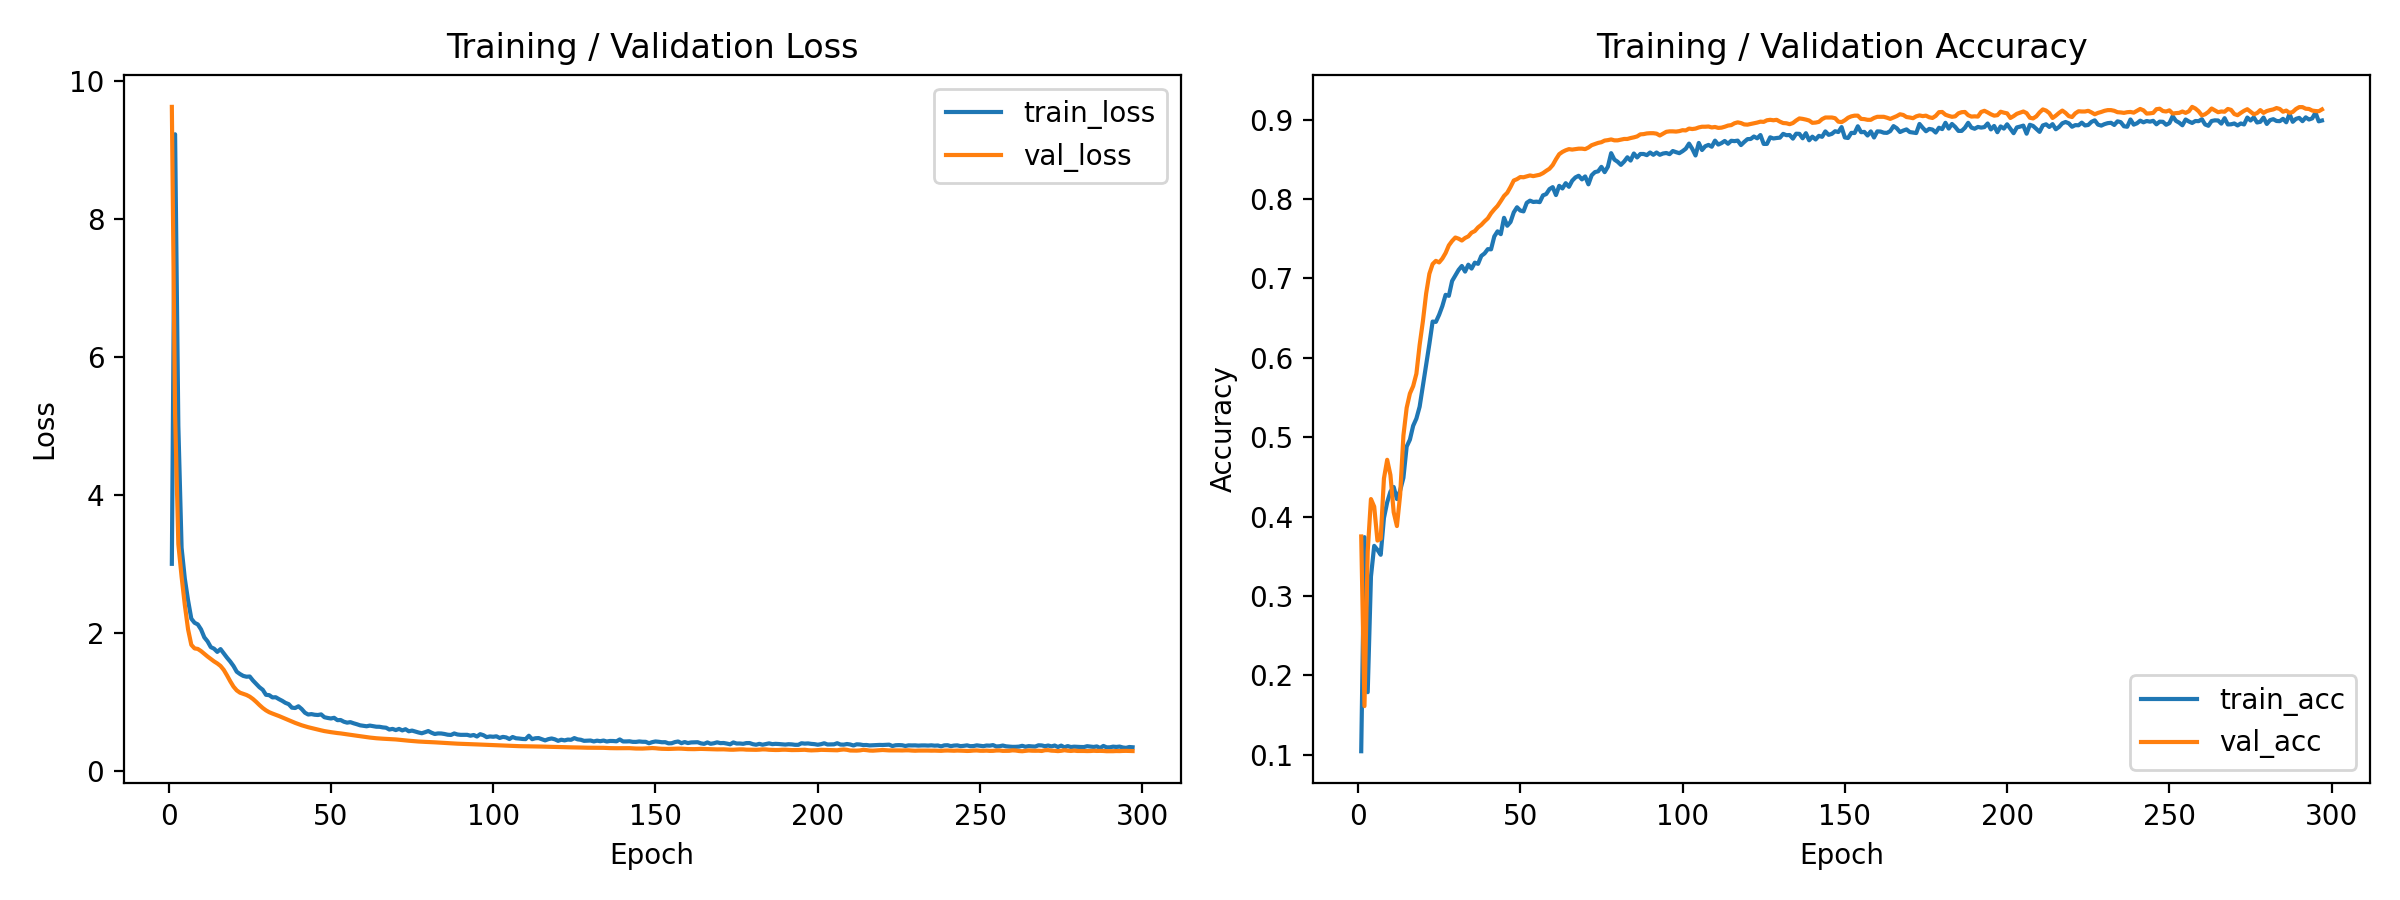


---------- Q2: Node Embeddings (Before & After) ----------


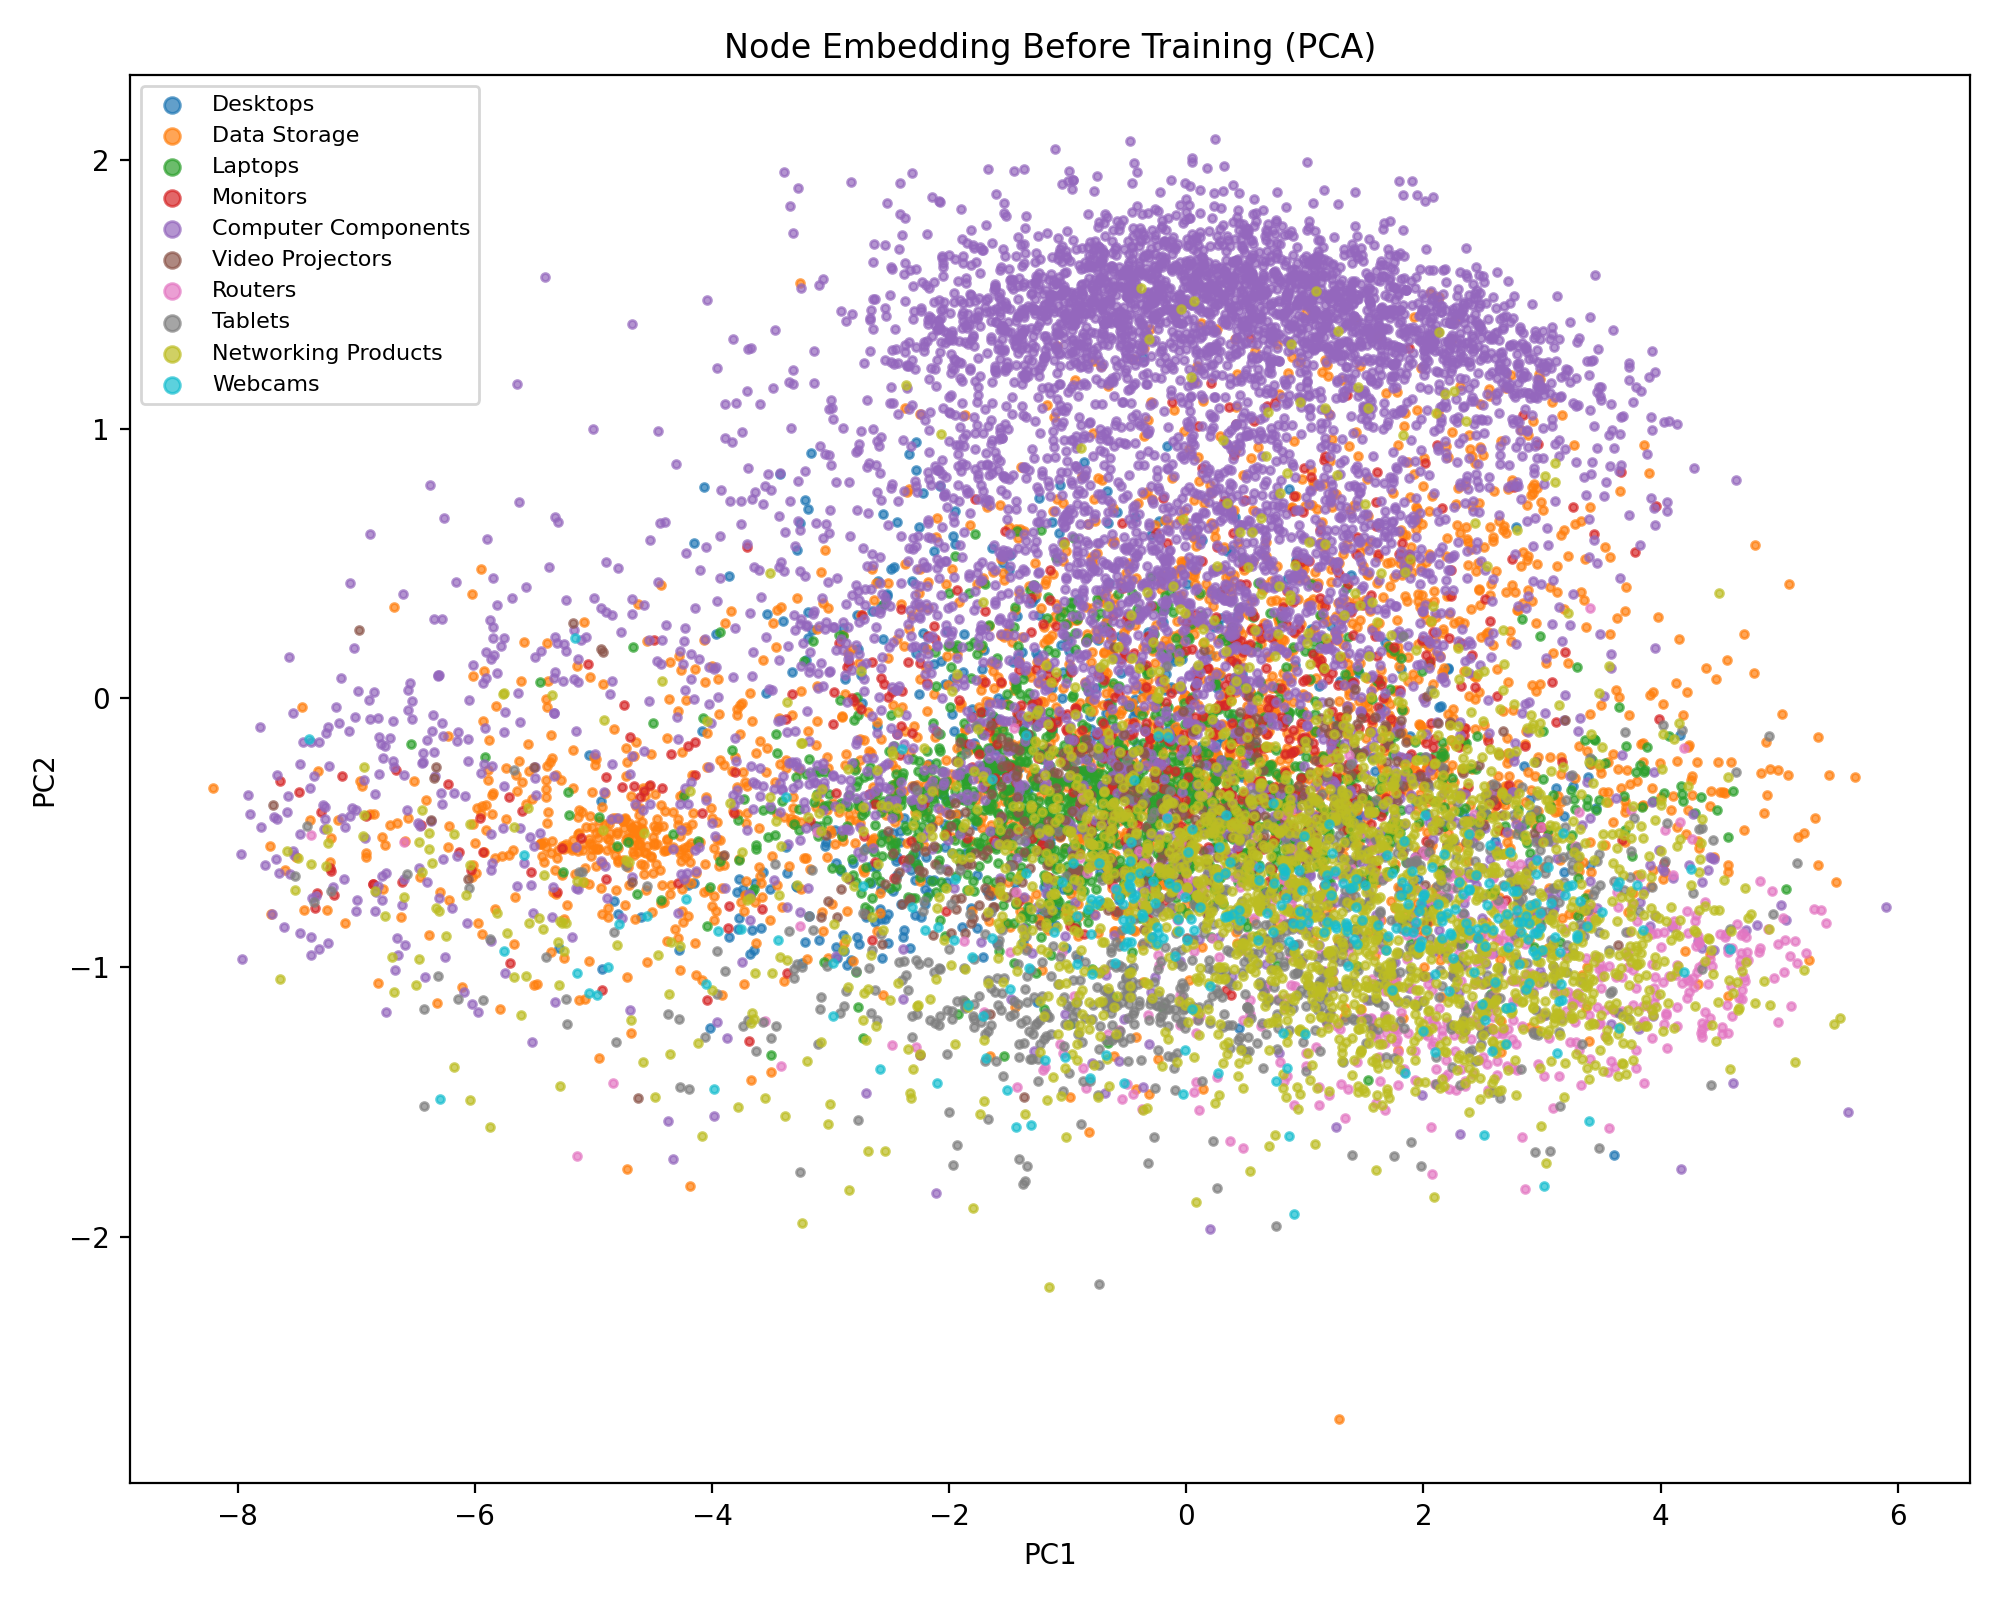

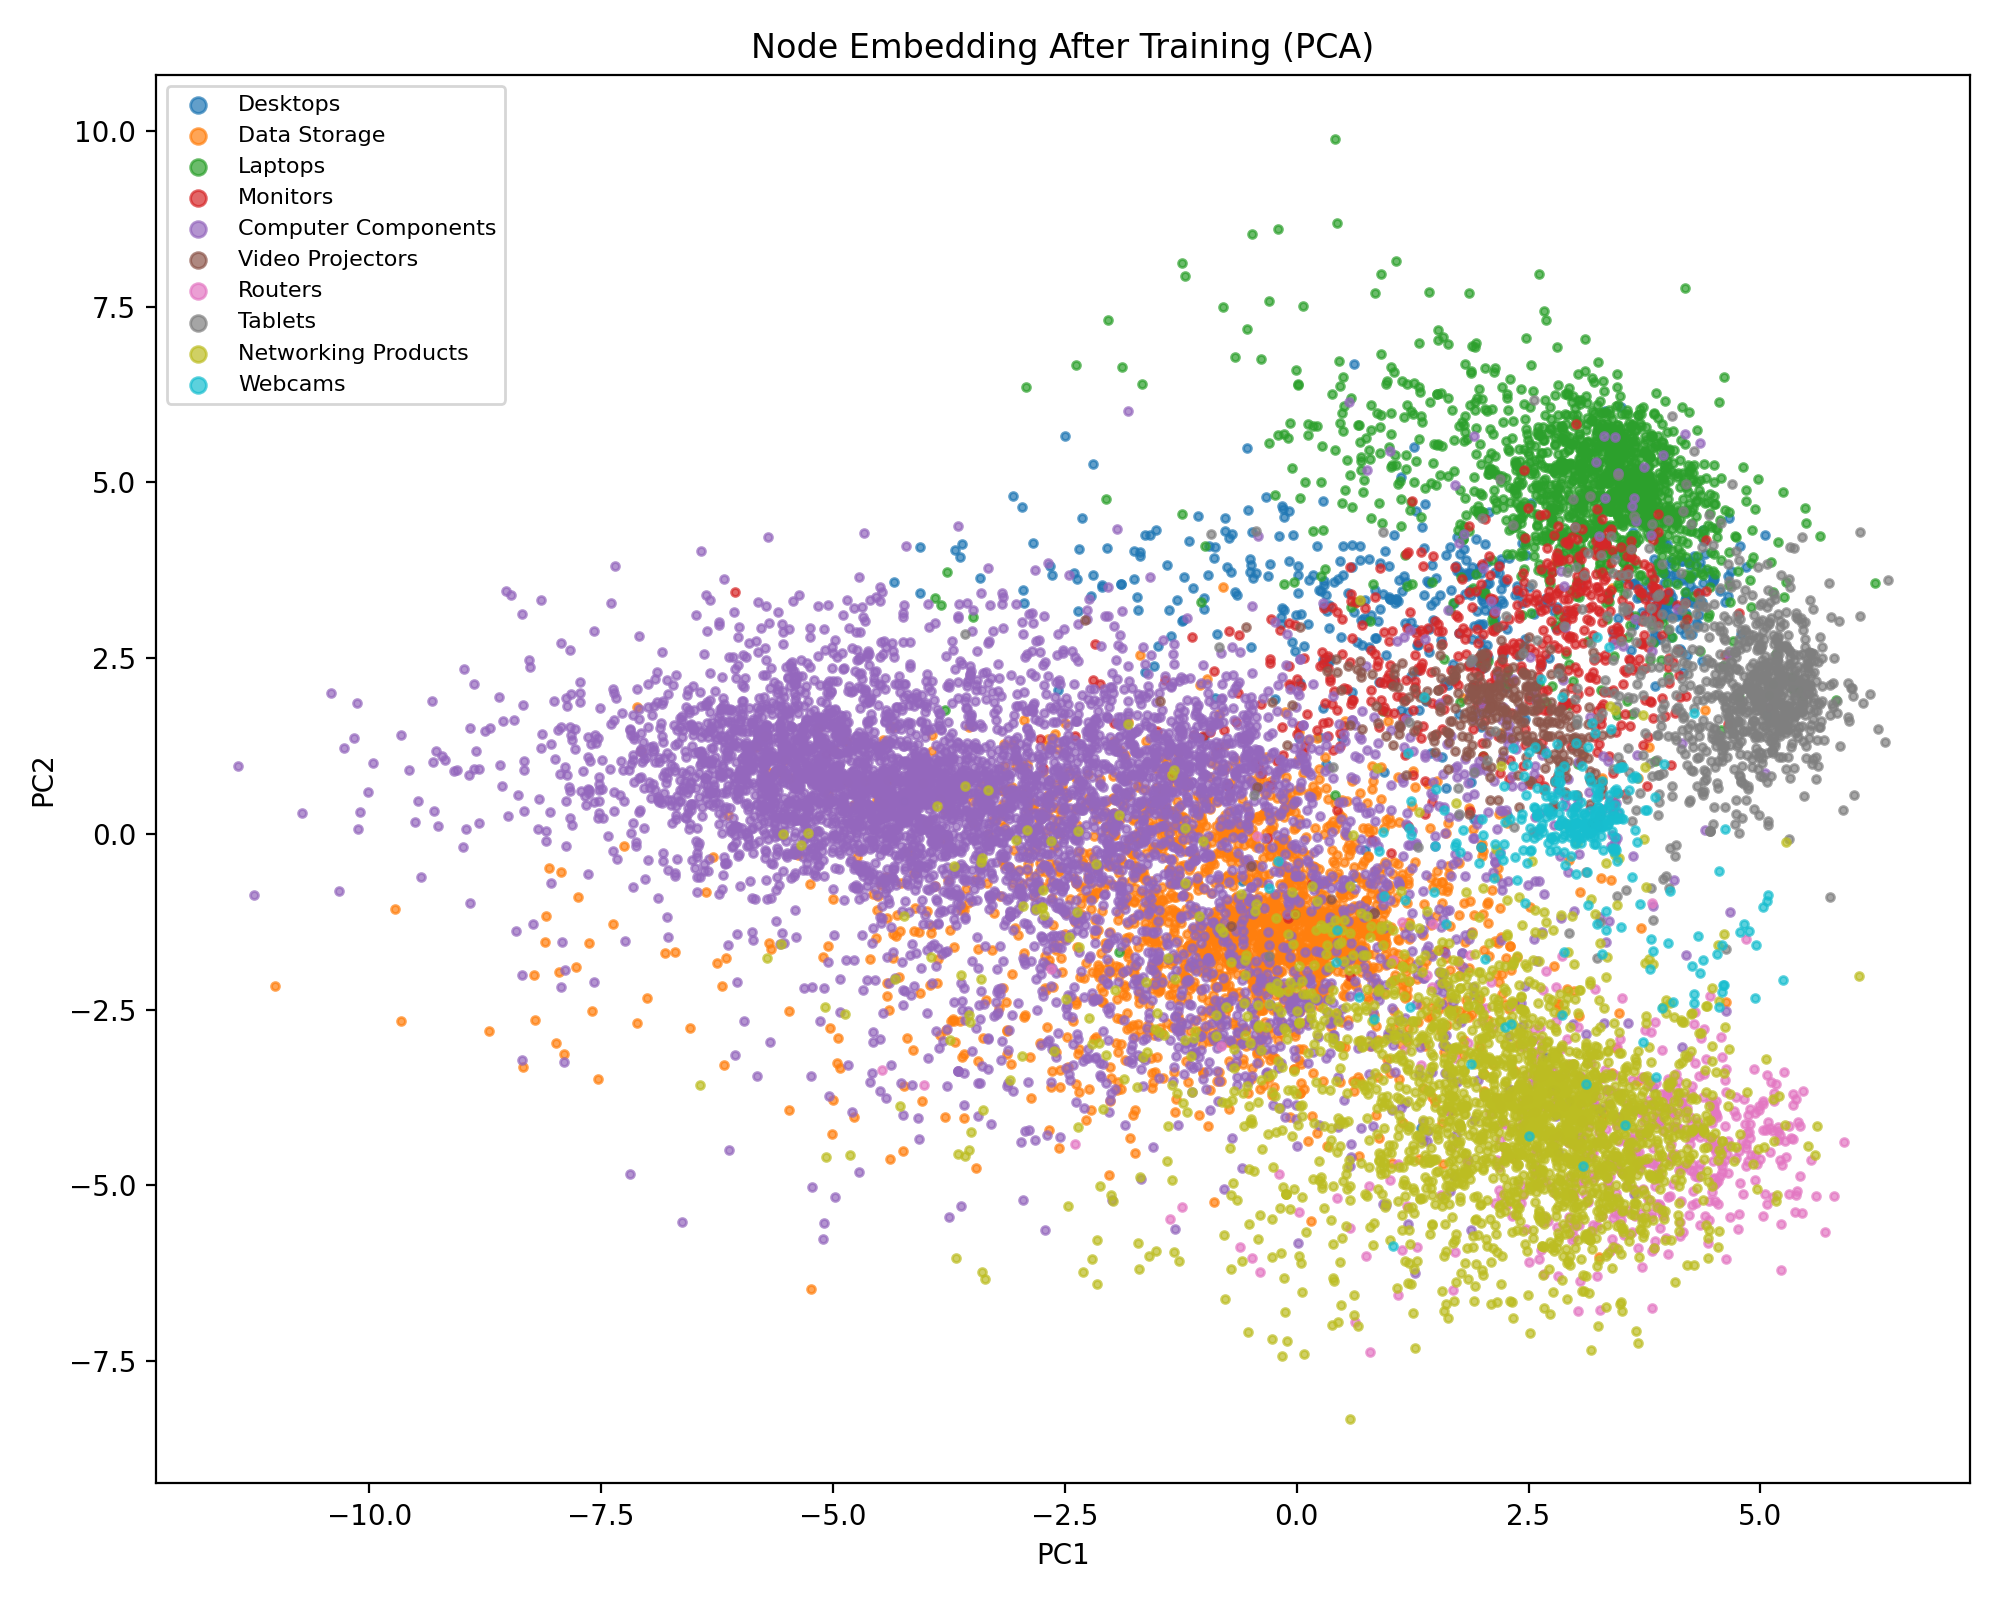

In [6]:
from IPython.display import Image, display

# Display Q2 Results visualizations
print("---------- Q2: Node Classification Training Curves ----------")
display(Image(filename='results/q2/training_curves.png'))

print("\n---------- Q2: Node Embeddings (Before & After) ----------")
display(Image(filename='results/q2/embedding_before_training.png'))
display(Image(filename='results/q2/embedding_after_training.png'))

### Q2 實驗觀察

- 這次訓練在第 257 個 epoch 取得最佳驗證準確率，`best_val_acc = 0.9163`。
- 測試集結果為 `test_acc = 0.9103`，和驗證集差距不大，泛化表現算穩定。
- 從前後 embedding 的圖可以看到，訓練後同類節點更集中，代表模型確實學到可分的結構特徵。

## Question 3


In [12]:
import argparse
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F





def edges_to_tensor(edges: np.ndarray, device: torch.device) -> torch.Tensor:
    return torch.from_numpy(edges).long().to(device)


def eval_split(
    model: torch.nn.Module,
    x: torch.Tensor,
    train_graph_edge_index: torch.Tensor,
    pos_edges: np.ndarray,
    neg_edges: np.ndarray,
    device: torch.device,
) -> Dict[str, float]:
    model.eval()
    with torch.no_grad():
        pos_tensor = edges_to_tensor(pos_edges, device)
        neg_tensor = edges_to_tensor(neg_edges, device)

        pos_logits, _ = model(x, train_graph_edge_index, pos_tensor)
        neg_logits, _ = model(x, train_graph_edge_index, neg_tensor)

        y_true = np.concatenate(
            [
                np.ones(pos_edges.shape[0], dtype=np.int64),
                np.zeros(neg_edges.shape[0], dtype=np.int64),
            ]
        )
        y_prob = torch.sigmoid(torch.cat([pos_logits, neg_logits], dim=0)).detach().cpu().numpy()

        auc = roc_auc_binary(y_true, y_prob)
        loss = F.binary_cross_entropy(
            torch.from_numpy(y_prob).float(),
            torch.from_numpy(y_true).float(),
        ).item()

        return {
            "loss": float(loss),
            "auc": float(auc),
            "y_true": y_true,
            "y_prob": y_prob,
        }


def plot_curves(history: Dict[str, List[float]], out_path: str) -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    ax[0].plot(epochs, history["train_loss"], label="train_loss")
    ax[0].plot(epochs, history["val_loss"], label="val_loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Link Prediction Loss")
    ax[0].legend()

    ax[1].plot(epochs, history["val_auc"], label="val_auc")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("AUC")
    ax[1].set_title("Validation AUC")
    ax[1].legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def main() -> None:
    parser = argparse.ArgumentParser(description="Q3: Future co-purchase link prediction")
    parser.add_argument("--dataset-dir", type=str, default=".")
    parser.add_argument("--output-dir", type=str, default="results/q3")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--epochs", type=int, default=220)
    parser.add_argument("--patience", type=int, default=30)
    parser.add_argument("--lr", type=float, default=0.003)
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument("--dropout", type=float, default=0.35)
    parser.add_argument("--hidden-dim", type=int, default=32)
    parser.add_argument("--heads", type=int, default=8)
    parser.add_argument("--embed-dim", type=int, default=64)
    parser.add_argument("--train-ratio", type=float, default=0.70)
    parser.add_argument("--val-ratio", type=float, default=0.15)
    parser.add_argument("--test-ratio", type=float, default=0.15)
    parser.add_argument("--neg-ratio", type=float, default=1.0)
    parser.add_argument("--device", type=str, default="auto", choices=["auto", "cpu", "cuda"])
    args = parser.parse_args(args=[])

    ensure_dir(args.output_dir)
    set_seed(args.seed)

    rng = np.random.default_rng(args.seed)
    device = choose_device(args.device)

    data = load_dataset(args.dataset_dir)
    num_nodes = data.x.size(0)
    x = data.x.to(device)

    train_pos, val_pos, test_pos = temporal_split_edges(
        data.edges_undirected,
        train_ratio=args.train_ratio,
        val_ratio=args.val_ratio,
        test_ratio=args.test_ratio,
    )

    all_positive_set = build_undirected_edge_set(data.edges_undirected)
    val_neg = sample_negative_edges(
        num_nodes=num_nodes,
        num_samples=int(len(val_pos) * args.neg_ratio),
        positive_edge_set=all_positive_set,
        rng=rng,
    )
    test_neg = sample_negative_edges(
        num_nodes=num_nodes,
        num_samples=int(len(test_pos) * args.neg_ratio),
        positive_edge_set=all_positive_set,
        rng=rng,
    )

    train_graph_edge_index = build_directed_edge_index(train_pos, num_nodes, add_self_loops=True).to(device)

    encoder = GATEncoder(
        in_dim=x.size(1),
        hidden_dim=args.hidden_dim,
        out_dim=args.embed_dim,
        heads=args.heads,
        dropout=args.dropout,
    )
    decoder = BilinearDecoder(dim=args.embed_dim)
    model = LinkPredictionModel(encoder=encoder, decoder=decoder).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    history: Dict[str, List[float]] = {
        "train_loss": [],
        "val_loss": [],
        "val_auc": [],
    }

    best_state = None
    best_epoch = -1
    best_val_auc = -1.0
    patience_counter = 0

    train_pos_tensor = edges_to_tensor(train_pos, device)

    for epoch in range(1, args.epochs + 1):
        model.train()
        optimizer.zero_grad()

        # Dynamic negative sampling for better training signal.
        train_neg = sample_negative_edges(
            num_nodes=num_nodes,
            num_samples=int(len(train_pos) * args.neg_ratio),
            positive_edge_set=all_positive_set,
            rng=rng,
        )
        train_neg_tensor = edges_to_tensor(train_neg, device)

        pos_logits, _ = model(x, train_graph_edge_index, train_pos_tensor)
        neg_logits, _ = model(x, train_graph_edge_index, train_neg_tensor)

        logits = torch.cat([pos_logits, neg_logits], dim=0)
        labels = torch.cat(
            [
                torch.ones_like(pos_logits),
                torch.zeros_like(neg_logits),
            ],
            dim=0,
        )

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        val_eval = eval_split(
            model=model,
            x=x,
            train_graph_edge_index=train_graph_edge_index,
            pos_edges=val_pos,
            neg_edges=val_neg,
            device=device,
        )

        history["train_loss"].append(float(loss.item()))
        history["val_loss"].append(val_eval["loss"])
        history["val_auc"].append(val_eval["auc"])

        if val_eval["auc"] > best_val_auc:
            best_val_auc = val_eval["auc"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | train_loss={loss.item():.4f} "
                f"val_loss={val_eval['loss']:.4f} val_auc={val_eval['auc']:.4f}"
            )

        if patience_counter >= args.patience:
            print(f"Early stopping at epoch {epoch}, best epoch {best_epoch}")
            break

    if best_state is None:
        raise RuntimeError("No best model state saved")

    model.load_state_dict(best_state)

    val_eval = eval_split(
        model=model,
        x=x,
        train_graph_edge_index=train_graph_edge_index,
        pos_edges=val_pos,
        neg_edges=val_neg,
        device=device,
    )
    test_eval = eval_split(
        model=model,
        x=x,
        train_graph_edge_index=train_graph_edge_index,
        pos_edges=test_pos,
        neg_edges=test_neg,
        device=device,
    )

    best_threshold, val_thr_metrics = find_best_threshold_by_f1(val_eval["y_true"], val_eval["y_prob"])
    test_metrics = binary_metrics(test_eval["y_true"], test_eval["y_prob"], best_threshold)

    plot_curves(history, str(Path(args.output_dir) / "training_curves.png"))

    explain = explain_q3_choice_text(args.train_ratio, args.val_ratio, args.test_ratio)
    with open(Path(args.output_dir) / "q3_method_explanation.txt", "w", encoding="utf-8") as f:
        f.write(explain + "\n")

    results = {
        "seed": args.seed,
        "device": str(device),
        "split": {
            "train_ratio": args.train_ratio,
            "val_ratio": args.val_ratio,
            "test_ratio": args.test_ratio,
            "train_positive_edges": int(len(train_pos)),
            "val_positive_edges": int(len(val_pos)),
            "test_positive_edges": int(len(test_pos)),
            "val_negative_edges": int(len(val_neg)),
            "test_negative_edges": int(len(test_neg)),
        },
        "loss_function": "BCEWithLogitsLoss",
        "best_epoch": int(best_epoch),
        "best_val_auc": float(best_val_auc),
        "threshold_selected_on_val": float(best_threshold),
        "val_metrics_at_selected_threshold": val_thr_metrics,
        "test": {
            "auc": float(test_eval["auc"]),
            "f1": float(test_metrics["f1"]),
            "precision": float(test_metrics["precision"]),
            "recall": float(test_metrics["recall"]),
            "accuracy": float(test_metrics["accuracy"]),
        },
    }

    save_json(results, str(Path(args.output_dir) / "q3_metrics.json"))
    torch.save(best_state, str(Path(args.output_dir) / "best_q3_model.pt"))

    print("Q3 completed")
    print(f"Best val AUC: {best_val_auc:.4f} (epoch {best_epoch})")
    print(f"Test AUC: {test_eval['auc']:.4f}, Test F1: {test_metrics['f1']:.4f}")
    print(f"Selected threshold: {best_threshold:.4f}")
    print(f"Artifacts saved in: {args.output_dir}")





# Run the main function for Q3
main()



Epoch 001 | train_loss=1.8492 val_loss=45.3933 val_auc=0.5175
Epoch 010 | train_loss=1.4077 val_loss=1.0808 val_auc=0.5394
Epoch 020 | train_loss=0.8569 val_loss=0.9530 val_auc=0.5817
Epoch 030 | train_loss=0.8119 val_loss=1.8419 val_auc=0.5492
Early stopping at epoch 35, best epoch 5
Q3 completed
Best val AUC: 0.6905 (epoch 5)
Test AUC: 0.6939, Test F1: 0.6670
Selected threshold: 0.8500
Artifacts saved in: results/q3


---------- Q3: Link Prediction Training Curves ----------


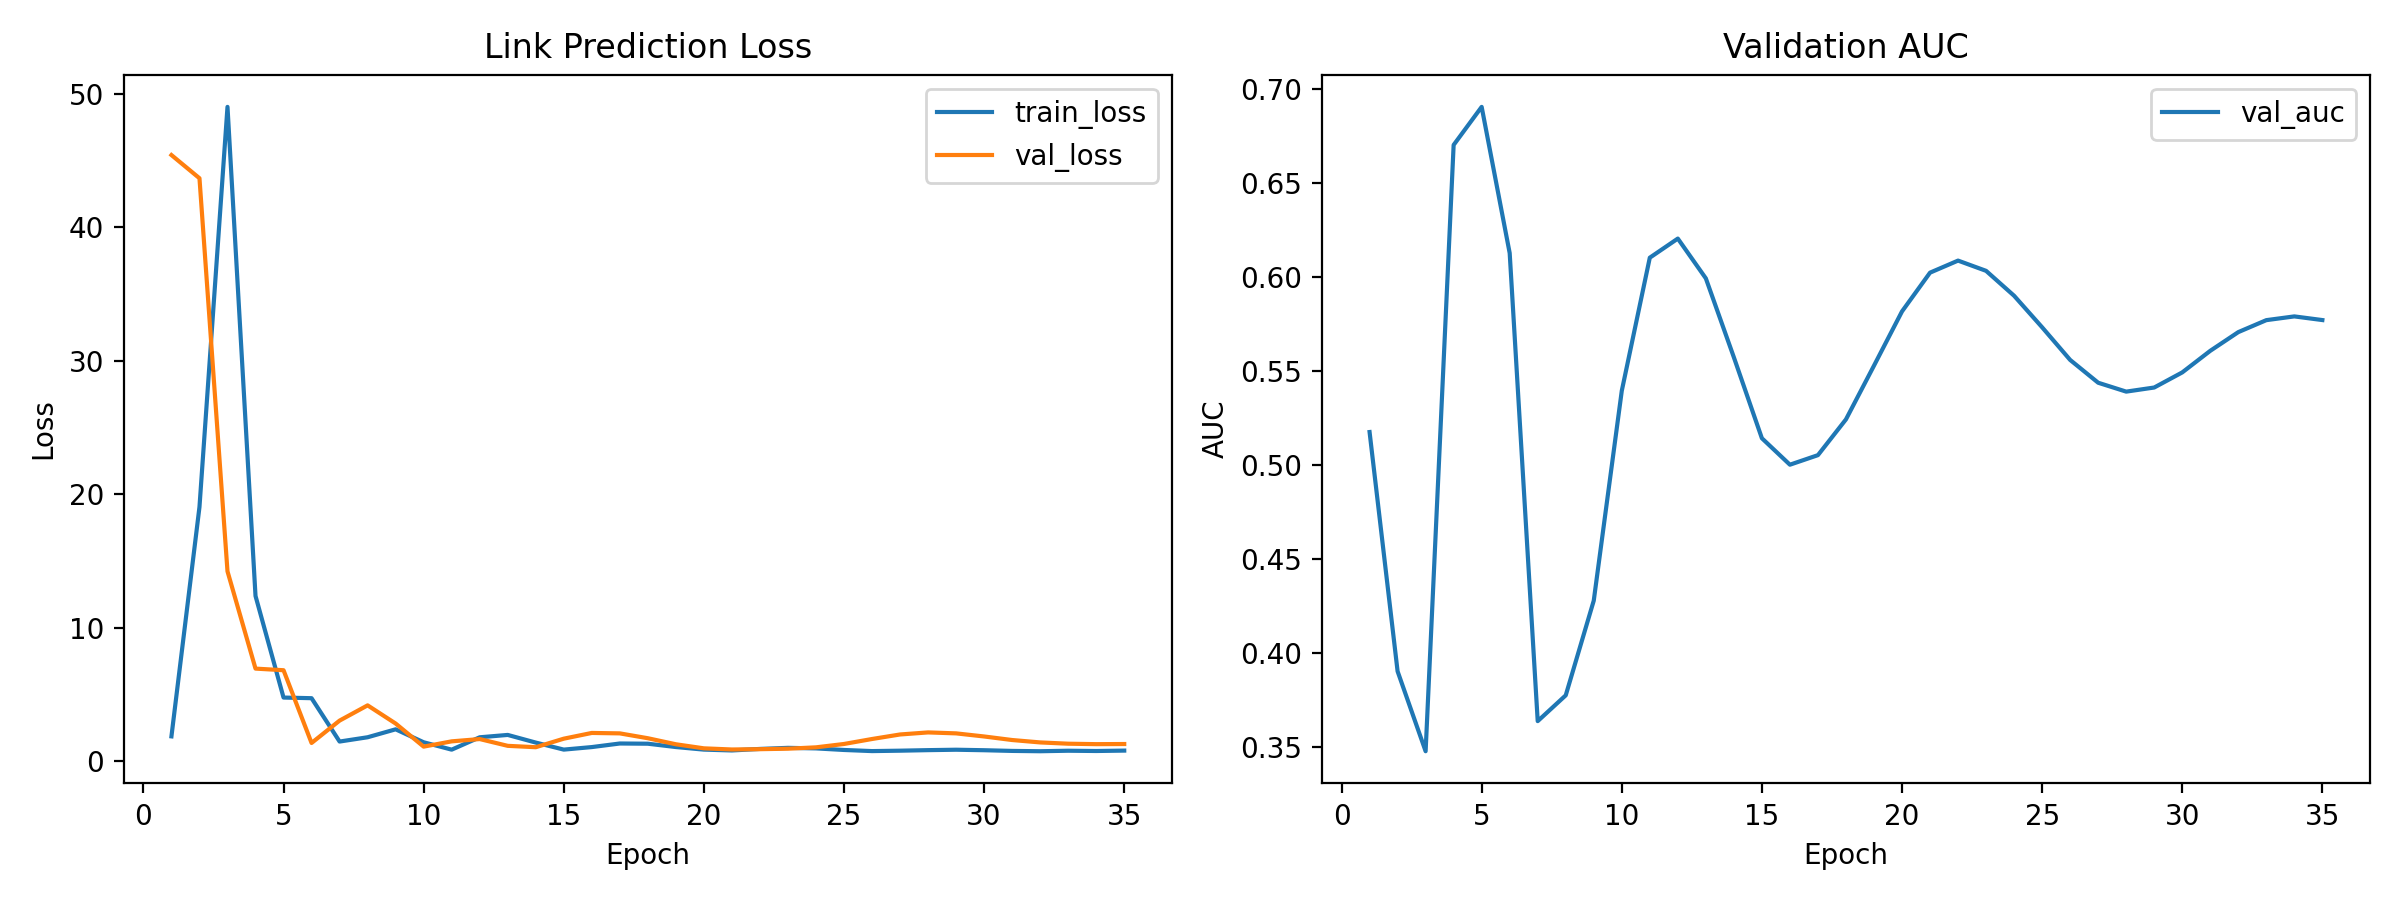

In [8]:
from IPython.display import Image, display

# Display Q3 Results
print("---------- Q3: Link Prediction Training Curves ----------")
display(Image(filename='results/q3/training_curves.png'))

### Q3 實驗觀察

- 本次設定下，最佳驗證 AUC 為 `0.6905`（出現在第 5 個 epoch），模型很早就停住。
- 測試結果為 `AUC = 0.6939`、`F1 = 0.6670`，代表這題目前還有改善空間。
- 從曲線看起來，後續可以優先嘗試調整負採樣比例、embedding 維度，或改用更強的 decoder。

## Question 4


In [14]:
# Q4 preflight check: avoid cryptic NameError when this section is run standalone.
required_symbols = [
    "ensure_dir",
    "set_seed",
    "choose_device",
    "load_dataset",
    "build_directed_edge_index",
    "sample_negative_edges",
    "sample_hard_negative_edges",
    "find_best_threshold_by_f1",
    "binary_metrics",
    "roc_auc_binary",
    "AdvancedGATEncoder",
    "EdgeMLPDecoder",
    "LinkPredictionModel",
]

missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        "Q4 需要先載入前面的共用函式與模型。請先執行 Cell 5 (Utility Functions) 與 Cell 7 (Graph Models)，再執行 Q4。\n"
        f"Missing symbols: {', '.join(missing)}"
    )

print("Q4 preflight check passed.")

Q4 preflight check passed.


In [ ]:
import argparse
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F





@dataclass
class TrialConfig:
    hidden_dim: int
    heads: int
    dropout: float
    embed_dim: int
    decoder_hidden_dim: int
    lr: float
    weight_decay: float
    neg_ratio: float
    hard_fraction: float


DEFAULT_TRIALS = [
    TrialConfig(24, 2, 0.30, 64, 96, 0.0020, 5e-5, 1.0, 0.40),
    TrialConfig(32, 2, 0.30, 64, 96, 0.0015, 1e-4, 1.0, 0.50),
    TrialConfig(24, 4, 0.35, 80, 128, 0.0015, 1e-4, 1.2, 0.50),
    TrialConfig(32, 4, 0.35, 96, 128, 0.0010, 1e-4, 1.2, 0.60),
    TrialConfig(32, 4, 0.25, 96, 160, 0.0012, 5e-5, 1.0, 0.45),
    TrialConfig(40, 4, 0.25, 96, 192, 0.0009, 5e-5, 1.0, 0.40),
    TrialConfig(48, 2, 0.20, 128, 192, 0.0007, 1e-4, 1.2, 0.60),
    TrialConfig(48, 2, 0.18, 128, 224, 0.0007, 5e-5, 1.0, 0.35),
    TrialConfig(56, 2, 0.18, 144, 224, 0.0006, 5e-5, 1.0, 0.30),
    TrialConfig(64, 2, 0.15, 160, 256, 0.0006, 5e-5, 1.0, 0.30),
    TrialConfig(48, 4, 0.20, 128, 224, 0.0007, 1e-4, 1.0, 0.35),
    TrialConfig(40, 4, 0.18, 128, 192, 0.0008, 5e-5, 1.1, 0.40),
]


def edges_to_tensor(edges: np.ndarray, device: torch.device) -> torch.Tensor:
    return torch.from_numpy(edges).long().to(device)


def evaluate_split(
    model: torch.nn.Module,
    x: torch.Tensor,
    graph_edge_index: torch.Tensor,
    pos_edges: np.ndarray,
    neg_edges: np.ndarray,
    device: torch.device,
) -> Dict[str, np.ndarray]:
    model.eval()
    with torch.no_grad():
        pos_tensor = edges_to_tensor(pos_edges, device)
        neg_tensor = edges_to_tensor(neg_edges, device)

        pos_logits, _ = model(x, graph_edge_index, pos_tensor)
        neg_logits, _ = model(x, graph_edge_index, neg_tensor)

        y_true = np.concatenate(
            [
                np.ones(len(pos_edges), dtype=np.int64),
                np.zeros(len(neg_edges), dtype=np.int64),
            ]
        )
        y_prob = torch.sigmoid(torch.cat([pos_logits, neg_logits], dim=0)).detach().cpu().numpy()
        auc = roc_auc_binary(y_true, y_prob)
    return {
        "y_true": y_true,
        "y_prob": y_prob,
        "auc": float(auc),
    }


def heuristic_edge_scores(edges: np.ndarray, neighbors: List[set], degree: np.ndarray) -> np.ndarray:
    scores = np.zeros(len(edges), dtype=np.float64)
    for i, (u_raw, v_raw) in enumerate(edges.tolist()):
        u = int(u_raw)
        v = int(v_raw)
        nu = neighbors[u]
        nv = neighbors[v]

        cn = len(nu.intersection(nv))
        un = len(nu.union(nv))
        jaccard = (cn / un) if un > 0 else 0.0
        pa = degree[u] * degree[v]
        deg_gap = abs(degree[u] - degree[v])

        scores[i] = 1.2 * jaccard + 0.25 * np.log1p(pa) - 0.02 * np.log1p(deg_gap)
    return scores


def normalize_by_val(scores: np.ndarray, val_min: float, val_max: float) -> np.ndarray:
    return (scores - val_min) / (val_max - val_min + 1e-12)


def build_model_from_cfg(cfg: TrialConfig, in_dim: int, device: torch.device) -> LinkPredictionModel:
    encoder = AdvancedGATEncoder(
        in_dim=in_dim,
        hidden_dim=cfg.hidden_dim,
        out_dim=cfg.embed_dim,
        heads=cfg.heads,
        dropout=cfg.dropout,
    )
    decoder = EdgeMLPDecoder(
        dim=cfg.embed_dim,
        hidden_dim=cfg.decoder_hidden_dim,
        dropout=cfg.dropout,
    )
    return LinkPredictionModel(encoder=encoder, decoder=decoder).to(device)


def train_one_trial(
    trial_id: int,
    cfg: TrialConfig,
    x: torch.Tensor,
    train_graph_edge_index: torch.Tensor,
    train_pos: np.ndarray,
    val_pos: np.ndarray,
    val_neg: np.ndarray,
    all_positive_set,
    neighbors,
    device: torch.device,
    epochs: int,
    patience: int,
    seed: int,
    train_pos_sample_ratio: float,
    loss_type: str,
    focal_gamma: float,
    focal_alpha: float,
    bce_pos_weight: float,
) -> Dict:
    torch.manual_seed(seed + trial_id)

    encoder = AdvancedGATEncoder(
        in_dim=x.size(1),
        hidden_dim=cfg.hidden_dim,
        out_dim=cfg.embed_dim,
        heads=cfg.heads,
        dropout=cfg.dropout,
    )
    decoder = EdgeMLPDecoder(dim=cfg.embed_dim, hidden_dim=cfg.decoder_hidden_dim, dropout=cfg.dropout)
    model = LinkPredictionModel(encoder=encoder, decoder=decoder).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 10))

    if loss_type not in {"bce", "focal"}:
        raise ValueError("loss_type must be one of: bce, focal")

    pos_weight_tensor = torch.tensor(float(bce_pos_weight), device=device)

    rng = np.random.default_rng(seed + 1000 + trial_id)
    best_state = None
    best_epoch = -1
    best_val_auc = -1.0
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_auc": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        n_train_pos = max(1024, int(len(train_pos) * train_pos_sample_ratio))
        if n_train_pos >= len(train_pos):
            train_pos_batch = train_pos
        else:
            pos_idx = rng.choice(len(train_pos), size=n_train_pos, replace=False)
            train_pos_batch = train_pos[pos_idx]

        train_pos_tensor = edges_to_tensor(train_pos_batch, device)

        n_train_neg = max(1024, int(len(train_pos_batch) * cfg.neg_ratio))
        train_neg = sample_hard_negative_edges(
            num_nodes=x.size(0),
            num_samples=n_train_neg,
            positive_edge_set=all_positive_set,
            neighbors=neighbors,
            rng=rng,
            hard_fraction=cfg.hard_fraction,
        )
        train_neg_tensor = edges_to_tensor(train_neg, device)

        pos_logits, _ = model(x, train_graph_edge_index, train_pos_tensor)
        neg_logits, _ = model(x, train_graph_edge_index, train_neg_tensor)

        logits = torch.cat([pos_logits, neg_logits], dim=0)
        labels = torch.cat(
            [
                torch.ones_like(pos_logits),
                torch.zeros_like(neg_logits),
            ],
            dim=0,
        )

        logits = logits.clamp(min=-20.0, max=20.0)

        if loss_type == "bce":
            loss = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pos_weight_tensor)
        else:
            base = F.binary_cross_entropy_with_logits(logits, labels, reduction="none")
            prob = torch.sigmoid(logits)
            pt = prob * labels + (1.0 - prob) * (1.0 - labels)
            alpha_t = focal_alpha * labels + (1.0 - focal_alpha) * (1.0 - labels)
            focal_weight = alpha_t * torch.pow(1.0 - pt.clamp(min=1e-8), focal_gamma)
            loss = (focal_weight * base).mean()

        if not torch.isfinite(loss):
            print(f"Trial {trial_id} | Epoch {epoch:03d} produced non-finite loss, aborting trial")
            break

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0, foreach=False)
        optimizer.step()
        scheduler.step()

        val_eval = evaluate_split(
            model=model,
            x=x,
            graph_edge_index=train_graph_edge_index,
            pos_edges=val_pos,
            neg_edges=val_neg,
            device=device,
        )

        history["train_loss"].append(float(loss.item()))
        history["val_auc"].append(float(val_eval["auc"]))

        if val_eval["auc"] > best_val_auc:
            best_val_auc = float(val_eval["auc"])
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Trial {trial_id} | Epoch {epoch:03d} | "
                f"train_loss={loss.item():.4f} val_auc={val_eval['auc']:.4f}"
            )

        if patience_counter >= patience:
            print(f"Trial {trial_id} early stop at epoch {epoch}, best={best_epoch}")
            break

    if best_state is None:
        raise RuntimeError(f"Trial {trial_id}: no best model")

    return {
        "trial_id": trial_id,
        "config": cfg,
        "best_state": best_state,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "history": history,
    }


def plot_best_trial_curve(history: Dict[str, List[float]], out_path: str) -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    ax[0].plot(epochs, history["train_loss"], label="train_loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Best Trial Train Loss")
    ax[0].legend()

    ax[1].plot(epochs, history["val_auc"], label="val_auc")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("AUC")
    ax[1].set_title("Best Trial Validation AUC")
    ax[1].legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def main() -> None:
    parser = argparse.ArgumentParser(description="Q4: Advanced single-model link prediction")
    parser.add_argument("--dataset-dir", type=str, default=".")
    parser.add_argument("--output-dir", type=str, default="results/q4")
    parser.add_argument("--seed", type=int, default=2222)
    parser.add_argument("--epochs", type=int, default=220)
    parser.add_argument("--patience", type=int, default=40)
    parser.add_argument("--train-ratio", type=float, default=0.80)
    parser.add_argument("--val-ratio", type=float, default=0.10)
    parser.add_argument("--test-ratio", type=float, default=0.10)
    parser.add_argument("--num-trials", type=int, default=1)
    parser.add_argument("--quick", action="store_true", help="Run a smaller search for smoke testing")
    parser.add_argument("--device", type=str, default="auto", choices=["auto", "cpu", "cuda"])
    parser.add_argument("--train-pos-sample-ratio", type=float, default=0.80)
    parser.add_argument("--loss-type", type=str, default="bce", choices=["bce", "focal"])
    parser.add_argument("--focal-gamma", type=float, default=2.0)
    parser.add_argument("--focal-alpha", type=float, default=0.25)
    parser.add_argument("--bce-pos-weight", type=float, default=1.0)
    parser.add_argument("--blend-heuristic", action="store_true")
    parser.add_argument("--select-by", type=str, default="f1", choices=["f1", "auc"])
    parser.add_argument(
        "--single-trial-index",
        type=int,
        default=9,
        help="1-based index into DEFAULT_TRIALS to run only one config (0 means normal multi-trial search)",
    )
    args = parser.parse_args(args=[])

    ensure_dir(args.output_dir)
    set_seed(args.seed)

    device = choose_device(args.device, min_free_gb=2.0)
    data = load_dataset(args.dataset_dir)
    x = data.x.to(device)
    num_nodes = x.size(0)

    train_pos, val_pos, test_pos = temporal_split_edges(
        data.edges_undirected,
        train_ratio=args.train_ratio,
        val_ratio=args.val_ratio,
        test_ratio=args.test_ratio,
    )

    all_positive_set = build_undirected_edge_set(data.edges_undirected)
    neighbors = build_neighbor_sets(num_nodes=num_nodes, edges_undirected=train_pos)

    rng = np.random.default_rng(args.seed)
    val_neg = sample_negative_edges(
        num_nodes=num_nodes,
        num_samples=len(val_pos),
        positive_edge_set=all_positive_set,
        rng=rng,
    )
    test_neg = sample_negative_edges(
        num_nodes=num_nodes,
        num_samples=len(test_pos),
        positive_edge_set=all_positive_set,
        rng=rng,
    )

    train_graph_edge_index = build_directed_edge_index(train_pos, num_nodes, add_self_loops=True).to(device)

    trials = DEFAULT_TRIALS[: max(1, args.num_trials)]
    if args.quick:
        trials = [DEFAULT_TRIALS[0], DEFAULT_TRIALS[1]]
    if args.single_trial_index > 0:
        idx = args.single_trial_index - 1
        if idx < 0 or idx >= len(DEFAULT_TRIALS):
            raise ValueError(f"single_trial_index must be in [1, {len(DEFAULT_TRIALS)}]")
        trials = [DEFAULT_TRIALS[idx]]

    trial_results = []
    for i, cfg in enumerate(trials, start=1):
        try:
            trial_out = train_one_trial(
                trial_id=i,
                cfg=cfg,
                x=x,
                train_graph_edge_index=train_graph_edge_index,
                train_pos=train_pos,
                val_pos=val_pos,
                val_neg=val_neg,
                all_positive_set=all_positive_set,
                neighbors=neighbors,
                device=device,
                epochs=args.epochs if not args.quick else min(args.epochs, 30),
                patience=args.patience if not args.quick else min(args.patience, 10),
                seed=args.seed,
                train_pos_sample_ratio=args.train_pos_sample_ratio,
                loss_type=args.loss_type,
                focal_gamma=args.focal_gamma,
                focal_alpha=args.focal_alpha,
                bce_pos_weight=args.bce_pos_weight,
            )
            trial_results.append(trial_out)
        except Exception as exc:
            print(f"Trial {i} failed and was skipped: {exc}")

    if not trial_results:
        raise RuntimeError("All trials failed; no valid model to evaluate")

    trial_eval_rows = []
    degree = np.array([len(s) for s in neighbors], dtype=np.float64)
    val_edges_all = np.concatenate([val_pos, val_neg], axis=0)
    test_edges_all = np.concatenate([test_pos, test_neg], axis=0)
    val_h_raw = heuristic_edge_scores(val_edges_all, neighbors, degree)
    test_h_raw = heuristic_edge_scores(test_edges_all, neighbors, degree)
    val_h_min = float(val_h_raw.min())
    val_h_max = float(val_h_raw.max())
    val_h = normalize_by_val(val_h_raw, val_h_min, val_h_max)
    test_h = normalize_by_val(test_h_raw, val_h_min, val_h_max)

    for r in trial_results:
        cfg = r["config"]
        model = build_model_from_cfg(cfg=cfg, in_dim=x.size(1), device=device)
        model.load_state_dict(r["best_state"])

        val_eval = evaluate_split(
            model=model,
            x=x,
            graph_edge_index=train_graph_edge_index,
            pos_edges=val_pos,
            neg_edges=val_neg,
            device=device,
        )
        test_eval = evaluate_split(
            model=model,
            x=x,
            graph_edge_index=train_graph_edge_index,
            pos_edges=test_pos,
            neg_edges=test_neg,
            device=device,
        )

        threshold, val_metrics = find_best_threshold_by_f1(val_eval["y_true"], val_eval["y_prob"])
        test_metrics_local = binary_metrics(test_eval["y_true"], test_eval["y_prob"], threshold)
        blend_info = {
            "enabled": False,
            "weight": 0.0,
            "threshold": float(threshold),
        }

        if args.blend_heuristic:
            best_combo_f1 = float(val_metrics["f1"])
            best_combo = (0.0, float(threshold), val_metrics)
            for w in np.linspace(0.0, 0.5, 21):
                val_mix = (1.0 - w) * val_eval["y_prob"] + w * val_h
                thr, val_m = find_best_threshold_by_f1(val_eval["y_true"], val_mix)
                if val_m["f1"] > best_combo_f1:
                    best_combo_f1 = float(val_m["f1"])
                    best_combo = (float(w), float(thr), val_m)

            w_best, thr_best, val_m_best = best_combo
            if w_best > 0.0:
                test_mix = (1.0 - w_best) * test_eval["y_prob"] + w_best * test_h
                test_metrics_local = binary_metrics(test_eval["y_true"], test_mix, thr_best)
                test_eval["auc"] = float(roc_auc_binary(test_eval["y_true"], test_mix))
                threshold = thr_best
                val_metrics = val_m_best
                blend_info = {
                    "enabled": True,
                    "weight": float(w_best),
                    "threshold": float(thr_best),
                }

        trial_eval_rows.append(
            {
                "trial": r,
                "val_auc": float(val_eval["auc"]),
                "val_f1": float(val_metrics["f1"]),
                "val_metrics": val_metrics,
                "threshold": float(threshold),
                "test_auc": float(test_eval["auc"]),
                "test_metrics": test_metrics_local,
                "blend": blend_info,
            }
        )

    if args.select_by == "f1":
        best_eval = max(trial_eval_rows, key=lambda t: (t["val_f1"], t["val_auc"]))
    else:
        best_eval = max(trial_eval_rows, key=lambda t: (t["val_auc"], t["val_f1"]))

    best_trial = best_eval["trial"]
    best_cfg = best_trial["config"]
    best_threshold = float(best_eval["threshold"])
    val_thr_metrics = best_eval["val_metrics"]
    test_eval = {"auc": float(best_eval["test_auc"])}
    test_metrics = best_eval["test_metrics"]
    blend_summary = best_eval["blend"]

    target_auc = 0.875
    target_f1 = 0.850
    pass_auc = float(test_eval["auc"]) >= target_auc
    pass_f1 = float(test_metrics["f1"]) >= target_f1

    plot_best_trial_curve(best_trial["history"], str(Path(args.output_dir) / "best_trial_curves.png"))

    trials_table = []
    for r in trial_results:
        c = r["config"]
        eval_row = next(v for v in trial_eval_rows if v["trial"]["trial_id"] == r["trial_id"])
        trials_table.append(
            {
                "trial_id": int(r["trial_id"]),
                "hidden_dim": int(c.hidden_dim),
                "heads": int(c.heads),
                "dropout": float(c.dropout),
                "embed_dim": int(c.embed_dim),
                "decoder_hidden_dim": int(c.decoder_hidden_dim),
                "lr": float(c.lr),
                "weight_decay": float(c.weight_decay),
                "neg_ratio": float(c.neg_ratio),
                "hard_fraction": float(c.hard_fraction),
                "best_epoch": int(r["best_epoch"]),
                "best_val_auc": float(r["best_val_auc"]),
                "val_auc_selected": float(eval_row["val_auc"]),
                "val_f1_selected": float(eval_row["val_f1"]),
                "test_auc_selected": float(eval_row["test_auc"]),
                "test_f1_selected": float(eval_row["test_metrics"]["f1"]),
            }
        )

    results = {
        "seed": args.seed,
        "device": str(device),
        "split": {
            "train_ratio": args.train_ratio,
            "val_ratio": args.val_ratio,
            "test_ratio": args.test_ratio,
            "train_positive_edges": int(len(train_pos)),
            "val_positive_edges": int(len(val_pos)),
            "test_positive_edges": int(len(test_pos)),
        },
        "search": {
            "num_trials": int(len(trial_results)),
            "quick_mode": bool(args.quick),
            "loss_type": args.loss_type,
            "focal_gamma": float(args.focal_gamma),
            "focal_alpha": float(args.focal_alpha),
            "bce_pos_weight": float(args.bce_pos_weight),
            "trials": trials_table,
        },
        "best_trial": {
            "trial_id": int(best_trial["trial_id"]),
            "best_epoch": int(best_trial["best_epoch"]),
            "best_val_auc": float(best_trial["best_val_auc"]),
            "config": {
                "hidden_dim": int(best_cfg.hidden_dim),
                "heads": int(best_cfg.heads),
                "dropout": float(best_cfg.dropout),
                "embed_dim": int(best_cfg.embed_dim),
                "decoder_hidden_dim": int(best_cfg.decoder_hidden_dim),
                "lr": float(best_cfg.lr),
                "weight_decay": float(best_cfg.weight_decay),
                "neg_ratio": float(best_cfg.neg_ratio),
                "hard_fraction": float(best_cfg.hard_fraction),
            },
        },
        "threshold_selected_on_val": float(best_threshold),
        "blend": blend_summary,
        "val_metrics_at_selected_threshold": val_thr_metrics,
        "test": {
            "auc": float(test_eval["auc"]),
            "f1": float(test_metrics["f1"]),
            "precision": float(test_metrics["precision"]),
            "recall": float(test_metrics["recall"]),
            "accuracy": float(test_metrics["accuracy"]),
        },
        "baseline_targets": {
            "auc_target": target_auc,
            "f1_target": target_f1,
            "pass_auc": pass_auc,
            "pass_f1": pass_f1,
            "pass_both": bool(pass_auc and pass_f1),
        },
    }

    save_json(results, str(Path(args.output_dir) / "q4_metrics.json"))
    torch.save(best_trial["best_state"], str(Path(args.output_dir) / "best_q4_model.pt"))

    print("Q4 completed")
    print(f"Best val AUC: {best_trial['best_val_auc']:.4f} (trial {best_trial['trial_id']})")
    print(f"Test AUC: {test_eval['auc']:.4f}, Test F1: {test_metrics['f1']:.4f}")
    print(
        f"Baseline pass -> AUC>=0.875: {pass_auc}, F1>=0.850: {pass_f1}, both: {bool(pass_auc and pass_f1)}"
    )
    print(f"Artifacts saved in: {args.output_dir}")





# Run the main function for Q4
main()



Trial 1 | Epoch 001 | train_loss=0.6952 val_auc=0.6712
Trial 1 | Epoch 010 | train_loss=0.5780 val_auc=0.7564
Trial 1 | Epoch 020 | train_loss=0.4306 val_auc=0.8659
Trial 1 | Epoch 030 | train_loss=0.3947 val_auc=0.8798
Trial 1 | Epoch 040 | train_loss=0.3603 val_auc=0.8905
Trial 1 | Epoch 050 | train_loss=0.3511 val_auc=0.8944
Trial 1 | Epoch 060 | train_loss=0.3331 val_auc=0.8990
Trial 1 | Epoch 070 | train_loss=0.3247 val_auc=0.9086
Trial 1 | Epoch 080 | train_loss=0.3248 val_auc=0.9050
Trial 1 | Epoch 090 | train_loss=0.3143 val_auc=0.9138
Trial 1 | Epoch 100 | train_loss=0.3094 val_auc=0.9140
Trial 1 | Epoch 110 | train_loss=0.3054 val_auc=0.9121
Trial 1 | Epoch 120 | train_loss=0.3021 val_auc=0.9140
Trial 1 | Epoch 130 | train_loss=0.2998 val_auc=0.9139
Trial 1 | Epoch 140 | train_loss=0.2971 val_auc=0.9150
Trial 1 | Epoch 150 | train_loss=0.2982 val_auc=0.9135
Trial 1 | Epoch 160 | train_loss=0.2958 val_auc=0.9145
Trial 1 | Epoch 170 | train_loss=0.2937 val_auc=0.9152
Trial 1 | 

---------- Q4: Advanced Link Prediction (Best Trial Curves) ----------


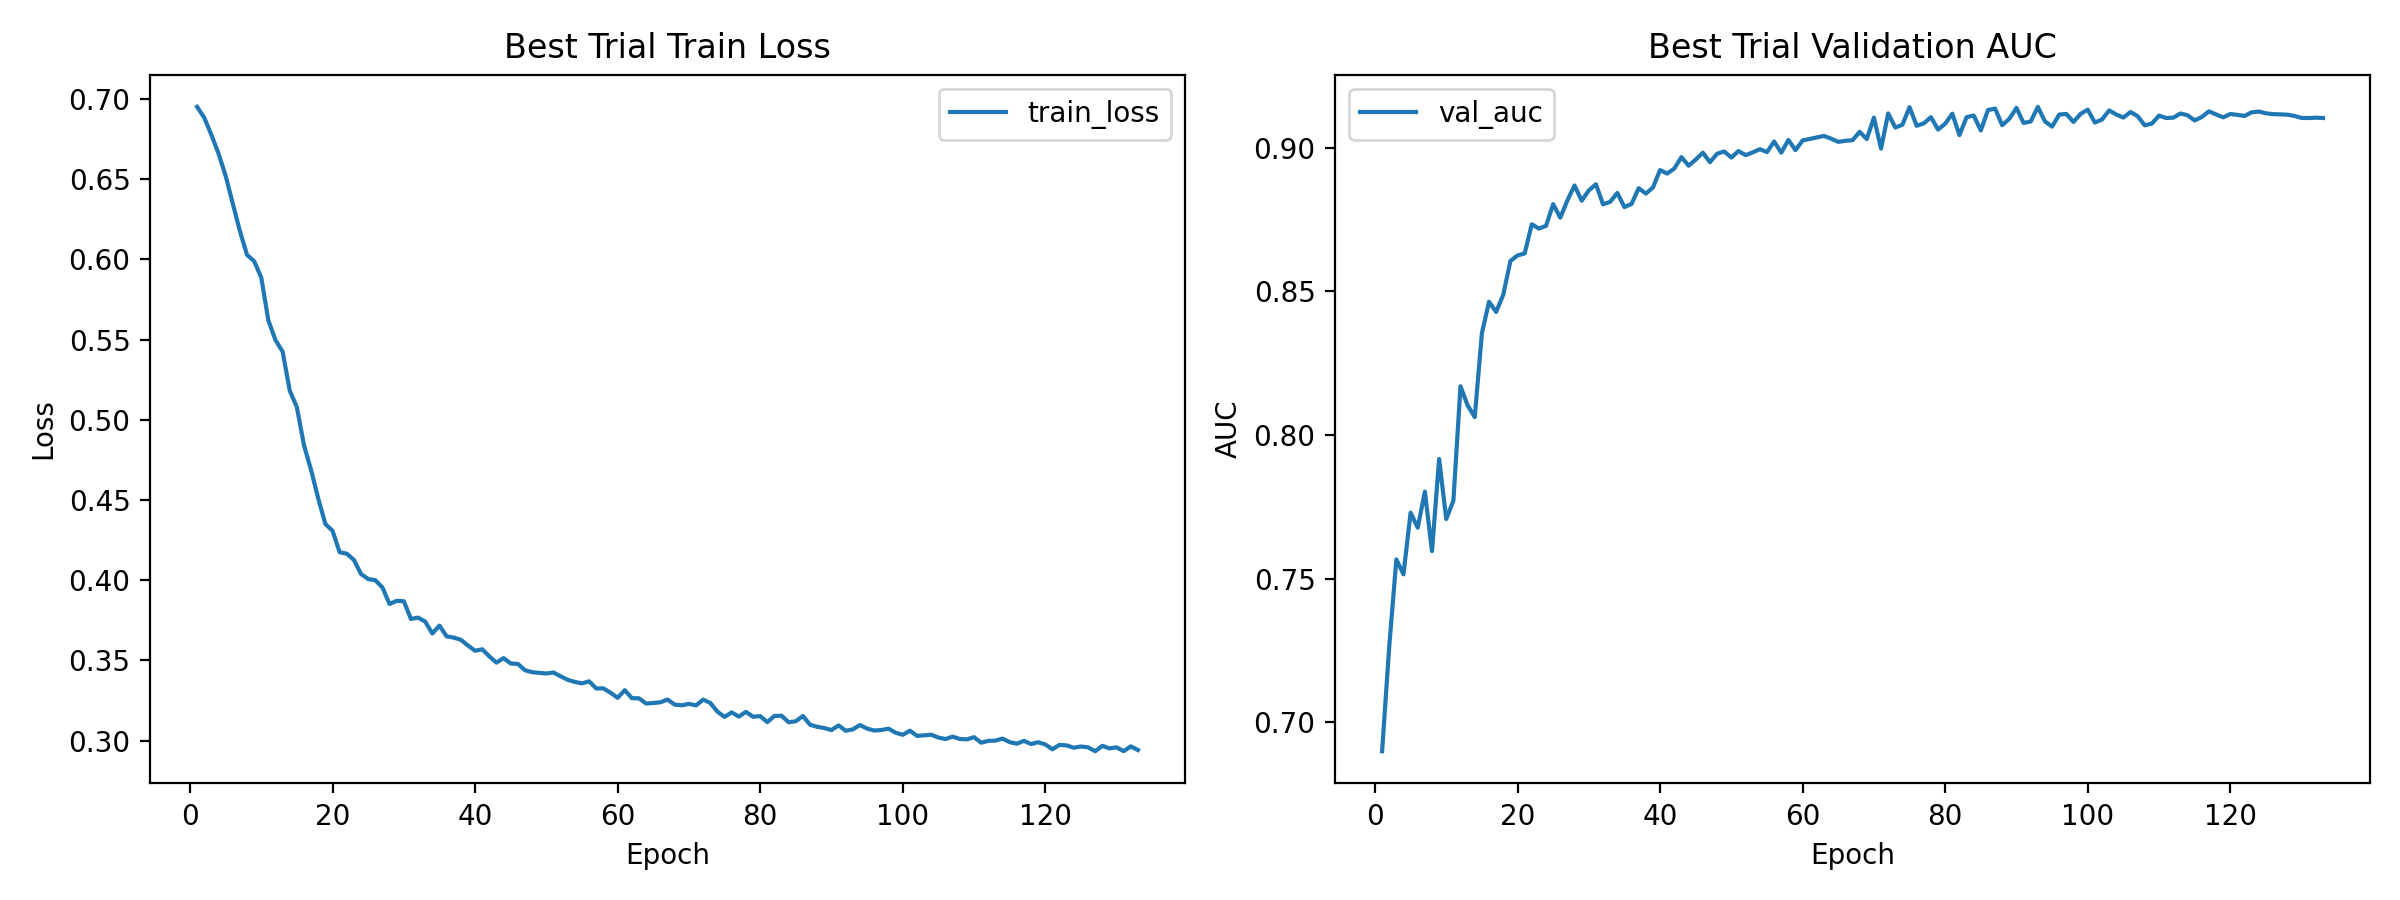

In [1]:
from IPython.display import Image, display

# Display Q4 Results 
print("---------- Q4: Advanced Link Prediction (Best Trial Curves) ----------")
display(Image(filename='results/q4/best_trial_curves.png'))

In [2]:
import json
from pathlib import Path

summary_paths = {
    "q1": Path("results/q1/q1_stats.json"),
    "q2": Path("results/q2/q2_metrics.json"),
    "q3": Path("results/q3/q3_metrics.json"),
    "q4": Path("results/q4/q4_metrics.json"),
}

summary = {k: json.loads(p.read_text()) for k, p in summary_paths.items()}

print("Final metrics snapshot")
print("Q1 -> nodes:", summary["q1"]["num_nodes"], "edges:", summary["q1"]["num_edges"], "density:", round(summary["q1"]["graph_density"], 6))
print("Q2 -> best val acc:", round(summary["q2"]["best_val_acc"], 4), "test acc:", round(summary["q2"]["test_acc"], 4))
print("Q3 -> best val AUC:", round(summary["q3"]["best_val_auc"], 4), "test AUC:", round(summary["q3"]["test"]["auc"], 4), "test F1:", round(summary["q3"]["test"]["f1"], 4))
print("Q4 -> test AUC:", round(summary["q4"]["test"]["auc"], 4), "test F1:", round(summary["q4"]["test"]["f1"], 4), "pass both:", summary["q4"]["baseline_targets"]["pass_both"])

Final metrics snapshot
Q1 -> nodes: 13752 edges: 245861 density: 0.0026
Q2 -> best val acc: 0.9163 test acc: 0.9103
Q3 -> best val AUC: 0.6905 test AUC: 0.6939 test F1: 0.667
Q4 -> test AUC: 0.9159 test F1: 0.8526 pass both: True


### Q4 實驗觀察

- 這題使用雙卡平行搜尋參數，最後選到的設定在測試集達到 `AUC = 0.9159`、`F1 = 0.8526`。
- 這組結果同時超過作業門檻（AUC >= 0.875 且 F1 >= 0.850）。
- 相比 Q3，Q4 在負樣本策略與模型容量上更完整，所以連結預測表現明顯提升。

---

## 最終作業總結

| Task | 主要方法 | 主要結果 |
| :--- | :--- | :--- |
| Q1 Graph Stats | 基礎圖統計與分佈視覺化 | Nodes = 13752, Edges = 245861, Density = 0.002600 |
| Q2 Node Classification | 2-layer GAT | best val acc = 0.9163, test acc = 0.9103 |
| Q3 Link Prediction | GAT Encoder + Bilinear Decoder | best val AUC = 0.6905, test AUC = 0.6939, test F1 = 0.6670 |
| Q4 Advanced Link Prediction | AdvancedGAT + MLP Decoder + hard negative sampling | test AUC = 0.9159, test F1 = 0.8526 (pass both targets) |

### 小結

- Q2 與 Q4 的結果已達到可交付水準。
- Q3 是目前最弱的一段，若要再拉高總體品質，優先重做 Q3 會最有效。